# Token Code Usage Under Dataset Shift

This notebook compares tokenizer code usage between the in-distribution reference set, `imagenet`, and one or more out-of-distribution datasets. The core hypothesis is simple: if a model has a stable and expressive discrete vocabulary, its active-code set, usage distribution, and spatial deployment of codes should remain relatively consistent when the input distribution shifts.


## Experiment Setup

The heavy computation happens outside the notebook. For each model and dataset pair, the export script writes:

- `summary.json`: compact run-level statistics.
- `global_counts.npy`: total count for each code ID across the full dataset.
- `position_counts.npy`: count for each `(code_id, row, col)` token-grid location.
- `usage.csv`: one row per code with count, frequency, activity flag, and rank.

This notebook stays light: it loads those artifacts, compares `imagenet` against all available OOD datasets, and then drills down into one selected OOD dataset for distribution and positional analysis.


## Export Procedure

The counting itself is done in the model-specific export scripts, not in the notebook. The procedure is the same at a high level for both LlamaGen and VQGAN:

1. Enumerate the dataset as an image folder with one subdirectory per class.
2. Resize and center-crop each image to the tokenizer input resolution.
3. Run the tokenizer encoder on the image batch.
4. Extract the discrete token indices produced by the quantizer.
5. Reshape the flat index stream into a `16 x 16` token grid per image.
6. Aggregate counts over the full dataset.

More concretely, if `z[i, r, c]` is the discrete code ID at image `i`, row `r`, column `c`, then the exports record two levels of counting:

- Global code usage: for each code `k`, count how many times `z[i, r, c] = k` over all images and all token positions.
- Positional code usage: for each code `k` and token position `(r, c)`, count how many images satisfy `z[i, r, c] = k`.

A code is considered **active** on a dataset if its global count is strictly greater than zero. A code is **dead** on that dataset if its global count is zero. This is why active/dead is dataset-specific, even though the underlying codebook size is fixed.

The notebook does not recompute these heavy counts. It only loads the exported aggregates and derives secondary summaries such as active-code overlap, perplexity, top-k mass, and positional entropy.


## Artifact Definitions

Each run directory contains the same small set of files. Their meanings are formal and fixed:

- `summary.json`: run metadata and scalar summaries. This includes dataset name, number of images, number of classes, token-grid shape, total token count, active/dead code counts, entropy, perplexity, and top-k mass statistics.
- `global_counts.npy`: a one-dimensional array of shape `(codebook_size,)`. Entry `global_counts[k]` is the total number of times code `k` appears anywhere in the dataset.
- `position_counts.npy`: a three-dimensional array of shape `(codebook_size, H, W)`. Entry `position_counts[k, r, c]` is the number of images for which code `k` appears at token-grid location `(r, c)`.
- `usage.csv`: a tabular version of the global counts, one row per code. It stores count, empirical frequency, whether the code is active, and the rank of the code after sorting by descending count.
- `top_codes.csv`: a compact table of the most frequently used codes, extracted from the same ranking used in `usage.csv`.

The basic consistency identity for a correct export is:

- `sum(global_counts) = sum(position_counts) = n_images * H * W`

because every image contributes exactly one code to every token-grid location.

The main derived quantities used later in the notebook are:

- **Active code count**: `|{k : global_counts[k] > 0}|`.
- **Active fraction of full codebook**: active code count divided by the full codebook size.
- **Perplexity**: `exp(H(p))`, where `p(k) = global_counts[k] / sum(global_counts)`. This is the effective number of codes after accounting for frequency imbalance.
- **Top-k mass**: the fraction of all token assignments captured by the `k` most frequently used codes.
- **Positional entropy**: for each token-grid location `(r, c)`, entropy of the conditional distribution `P(code | r, c)` estimated from `position_counts[:, r, c]`.
- **Code-position map**: for a fixed code `k`, the normalized grid derived from `position_counts[k, :, :]`, where the grid sums to one over token positions. This describes where that specific code tends to appear when it appears at all.
- **Code-position diffusion**: the effective number of grid locations used by a fixed code, computed as `exp(H(P(position | code)))`. A large value means the code is spatially spread out; a small value means it is concentrated in a few positions.
- **Code-position sparsity**: the fraction of grid cells with zero mass for a fixed code. A larger value means the code appears in fewer grid locations.

- **Perplexity** is the effective number of codes being used after accounting for imbalance. Higher means broader usage.
- **Top-10/100/500** mass is the fraction of all token assignments captured by the 10, 100, or 500 most-used codes. Higher means more concentration.


In [23]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('../code_usage_results')
RECON_METRICS_PATH = Path('data/end_to_end_metrics_numeric.csv')
MODEL_DIRS = {
    'LlamaGen': RESULTS_ROOT / 'llamagen',
    'VQGAN': RESULTS_ROOT / 'vqgan',
}
IN_DISTRIBUTION_DATASET = 'imagenet'


In [36]:
PLOTS_DIR = Path("code_usage_plots")
PLOTS_DIR.mkdir(exist_ok=True)

def save_current_plot(name):
    path = PLOTS_DIR / f"{name}.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved: {path}")


In [24]:
def load_run(run_dir):
    summary = json.loads((run_dir / 'summary.json').read_text())
    global_counts = np.load(run_dir / 'global_counts.npy')
    position_counts = np.load(run_dir / 'position_counts.npy')
    usage = pd.read_csv(run_dir / 'usage.csv')
    return {
        'summary': summary,
        'global_counts': global_counts,
        'position_counts': position_counts,
        'usage': usage,
    }


def discover_datasets():
    datasets_per_model = {}
    for model, model_dir in MODEL_DIRS.items():
        datasets_per_model[model] = sorted(path.name for path in model_dir.iterdir() if path.is_dir())
    shared = sorted(set.intersection(*[set(names) for names in datasets_per_model.values()]))
    return datasets_per_model, shared


def load_runs(dataset_names):
    runs = {}
    for model, model_dir in MODEL_DIRS.items():
        runs[model] = {}
        for dataset in dataset_names:
            runs[model][dataset] = load_run(model_dir / dataset)
    return runs


def active_mask(global_counts):
    return global_counts > 0


def position_entropy(position_counts):
    totals = position_counts.sum(axis=0, keepdims=True)
    probs = np.divide(position_counts, totals, out=np.zeros_like(position_counts, dtype=np.float64), where=totals > 0)
    log_probs = np.zeros_like(probs)
    mask = probs > 0
    log_probs[mask] = np.log(probs[mask])
    return -(probs * log_probs).sum(axis=0)


def normalized_code_position_map(position_counts, code_id):
    grid = position_counts[code_id].astype(np.float64)
    total = grid.sum()
    return grid / total if total > 0 else grid




def code_position_stats(position_counts, code_id):
    grid = normalized_code_position_map(position_counts, code_id)
    nonzero = grid > 0
    log_grid = np.zeros_like(grid)
    log_grid[nonzero] = np.log(grid[nonzero])
    entropy = float(-(grid * log_grid).sum())
    return {
        'code_id': code_id,
        'code_total': int(position_counts[code_id].sum()),
        'position_entropy': entropy,
        'position_perplexity': float(np.exp(entropy)) if grid.sum() > 0 else 0.0,
        'zero_position_fraction': float((grid == 0).mean()),
        'max_position_mass': float(grid.max()) if grid.size else 0.0,
    }


def code_position_l1_distance(position_counts_a, position_counts_b, code_id):
    a = normalized_code_position_map(position_counts_a, code_id)
    b = normalized_code_position_map(position_counts_b, code_id)
    return float(np.abs(a - b).sum())



def display_dataset_name(dataset):
    return {
        'imagenet': 'ImageNet',
        'imagenet_v2': 'ImageNet-V2',
        'imagenet_sketch': 'ImageNet-Sketch',
        'objectnet': 'ObjectNet',
        'rvlcdip': 'RVL-CDIP',
        'bloodmnist': 'BloodMNIST',
        'organamnist': 'OrganAMNIST',
    }.get(dataset, dataset)


def load_reconstruction_metrics(path=RECON_METRICS_PATH):
    df = pd.read_csv(path)
    reverse_names = {
        'ImageNet': 'imagenet',
        'ImageNet-V2': 'imagenet_v2',
        'ImageNet-Sketch': 'imagenet_sketch',
        'ObjectNet': 'objectnet',
        'RVL-CDIP': 'rvlcdip',
        'BloodMNIST': 'bloodmnist',
        'OrganAMNIST': 'organamnist',
    }
    df = df.copy()
    df['dataset_key'] = df['dataset'].map(reverse_names).fillna(df['dataset'])
    return df


def make_code_reconstruction_table(summary_df, recon_df):
    metric_cols = [
        'psnr_mean', 'psnr_std', 'ssim_mean', 'ssim_std',
        'lpips_mean', 'lpips_std', 'fid', 'sfid',
        'precision', 'recall', 'inception',
    ]
    merged = summary_df.merge(
        recon_df[['model', 'dataset_key'] + metric_cols],
        left_on=['model', 'dataset'],
        right_on=['model', 'dataset_key'],
        how='left',
    ).drop(columns=['dataset_key'])
    merged['dataset_label'] = merged['dataset'].map(display_dataset_name)
    return merged


def make_summary_rows(runs, dataset_names):
    rows = []
    for model, model_runs in runs.items():
        imagenet_active = model_runs[IN_DISTRIBUTION_DATASET]['summary']['active_codes']
        imagenet_mask = active_mask(model_runs[IN_DISTRIBUTION_DATASET]['global_counts'])
        for dataset in dataset_names:
            run = model_runs[dataset]
            summary = run['summary']
            dataset_mask = active_mask(run['global_counts'])
            rows.append({
                'model': model,
                'dataset': dataset,
                'n_images': summary['n_images'],
                'active_codes': summary['active_codes'],
                'dead_codes': summary['dead_codes'],
                'active_fraction_full': summary['active_fraction_full'],
                'active_fraction_vs_imagenet': summary['active_codes'] / imagenet_active,
                'active_overlap_with_imagenet': (dataset_mask & imagenet_mask).sum() / imagenet_active,
                'perplexity': summary['perplexity'],
                'top_10_mass': summary['top_10_mass'],
                'top_100_mass': summary['top_100_mass'],
                'top_500_mass': summary['top_500_mass'],
            })
    return pd.DataFrame(rows)


datasets_per_model, shared_datasets = discover_datasets()
assert IN_DISTRIBUTION_DATASET in shared_datasets, 'ImageNet baseline results are required.'
ood_datasets = [name for name in shared_datasets if name != IN_DISTRIBUTION_DATASET]
comparison_datasets = [IN_DISTRIBUTION_DATASET] + ood_datasets
runs = load_runs(comparison_datasets)
summary_df = make_summary_rows(runs, comparison_datasets)
recon_df = load_reconstruction_metrics()
combined_df = make_code_reconstruction_table(summary_df, recon_df)


Shared datasets: ['bloodmnist', 'imagenet', 'imagenet_sketch', 'imagenet_v2', 'objectnet', 'organamnist', 'rvlcdip']


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,imagenet,50000,16384,0,1.000000,1.000000,1.000000,16179.189378,0.002933,0.011967,0.045642
1,LlamaGen,bloodmnist,17092,16124,260,0.984131,0.984131,0.984131,5810.776916,0.023922,0.129320,0.323858
2,LlamaGen,imagenet_sketch,50889,16383,1,0.999939,0.999939,0.999939,6095.064781,0.095202,0.186389,0.302988
3,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.000000,1.000000,16094.903809,0.002756,0.012407,0.047786
4,LlamaGen,objectnet,50273,16384,0,1.000000,1.000000,1.000000,14817.435854,0.006668,0.029941,0.089336


In [26]:
print('Shared datasets:', shared_datasets)
summary_df

Shared datasets: ['bloodmnist', 'imagenet', 'imagenet_sketch', 'imagenet_v2', 'objectnet', 'organamnist', 'rvlcdip']


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,imagenet,50000,16384,0,1.000000,1.000000,1.000000,16179.189378,0.002933,0.011967,0.045642
1,LlamaGen,bloodmnist,17092,16124,260,0.984131,0.984131,0.984131,5810.776916,0.023922,0.129320,0.323858
2,LlamaGen,imagenet_sketch,50889,16383,1,0.999939,0.999939,0.999939,6095.064781,0.095202,0.186389,0.302988
3,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.000000,1.000000,16094.903809,0.002756,0.012407,0.047786
4,LlamaGen,objectnet,50273,16384,0,1.000000,1.000000,1.000000,14817.435854,0.006668,0.029941,0.089336
5,LlamaGen,organamnist,57187,16383,1,0.999939,0.999939,0.999939,10099.191216,0.026950,0.070029,0.167338
6,LlamaGen,rvlcdip,39996,16288,96,0.994141,0.994141,0.994141,3721.318354,0.113131,0.216333,0.367508
7,VQGAN,imagenet,50000,972,15412,0.059326,1.000000,1.000000,910.464663,0.021549,0.164769,0.664882
8,VQGAN,bloodmnist,17092,966,15418,0.058960,0.993827,0.993827,452.208064,0.120359,0.449999,0.937367
9,VQGAN,imagenet_sketch,50889,972,15412,0.059326,1.000000,1.000000,411.380910,0.228792,0.455783,0.850975


## Quick Validation

Each exported run should satisfy one invariant: the global token count must match the sum over all position-specific counts, and both must equal `n_images * H * W`.


In [27]:
validation_rows = []
for model, model_runs in runs.items():
    for dataset, run in model_runs.items():
        summary = run['summary']
        global_total = int(run['global_counts'].sum())
        position_total = int(run['position_counts'].sum())
        h, w = summary['token_grid_hw']
        expected_total = summary['n_images'] * h * w
        validation_rows.append({
            'model': model,
            'dataset': dataset,
            'global_total': global_total,
            'position_total': position_total,
            'expected_total': expected_total,
            'ok': global_total == position_total == expected_total,
        })

pd.DataFrame(validation_rows).sort_values(['dataset', 'model']).reset_index(drop=True)


,model,dataset,global_total,position_total,expected_total,ok
0,LlamaGen,bloodmnist,4375552,4375552,4375552,True
1,VQGAN,bloodmnist,4375552,4375552,4375552,True
2,LlamaGen,imagenet,12800000,12800000,12800000,True
3,VQGAN,imagenet,12800000,12800000,12800000,True
4,LlamaGen,imagenet_sketch,13027584,13027584,13027584,True
5,VQGAN,imagenet_sketch,13027584,13027584,13027584,True
6,LlamaGen,imagenet_v2,2560000,2560000,2560000,True
7,VQGAN,imagenet_v2,2560000,2560000,2560000,True
8,LlamaGen,objectnet,12869888,12869888,12869888,True
9,VQGAN,objectnet,12869888,12869888,12869888,True


## Run-Level Summary Across Datasets

This table is the main compact view. `active_fraction_vs_imagenet` answers the baseline-normalized question directly: for each model, what fraction of the ImageNet active vocabulary remains active on each OOD dataset?


In [28]:
summary_df = summary_df.sort_values(['dataset', 'model']).reset_index(drop=True)
summary_df


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,bloodmnist,17092,16124,260,0.984131,0.984131,0.984131,5810.776916,0.023922,0.129320,0.323858
1,VQGAN,bloodmnist,17092,966,15418,0.058960,0.993827,0.993827,452.208064,0.120359,0.449999,0.937367
2,LlamaGen,imagenet,50000,16384,0,1.000000,1.000000,1.000000,16179.189378,0.002933,0.011967,0.045642
3,VQGAN,imagenet,50000,972,15412,0.059326,1.000000,1.000000,910.464663,0.021549,0.164769,0.664882
4,LlamaGen,imagenet_sketch,50889,16383,1,0.999939,0.999939,0.999939,6095.064781,0.095202,0.186389,0.302988
5,VQGAN,imagenet_sketch,50889,972,15412,0.059326,1.000000,1.000000,411.380910,0.228792,0.455783,0.850975
6,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.000000,1.000000,16094.903809,0.002756,0.012407,0.047786
7,VQGAN,imagenet_v2,10000,972,15412,0.059326,1.000000,1.000000,911.084478,0.021474,0.164576,0.663230
8,LlamaGen,objectnet,50273,16384,0,1.000000,1.000000,1.000000,14817.435854,0.006668,0.029941,0.089336
9,VQGAN,objectnet,50273,972,15412,0.059326,1.000000,1.000000,875.461379,0.024355,0.197147,0.699826


## Active Code Count by Dataset

The first comparison is absolute utilization: how many codes become active on each dataset for each model.


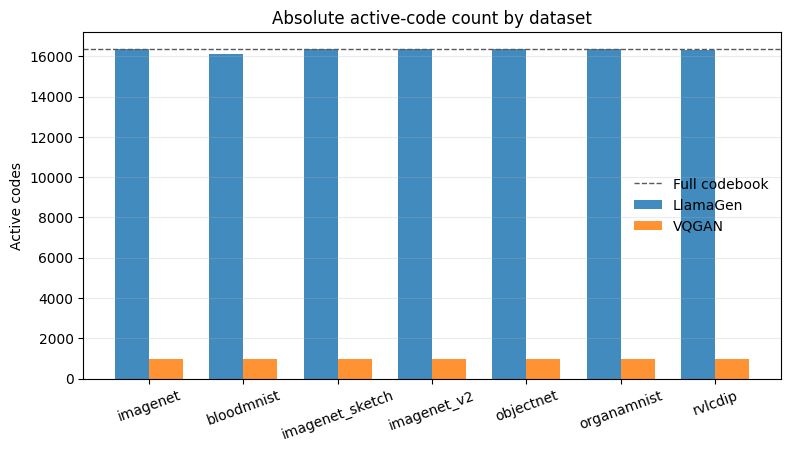

In [29]:
datasets = comparison_datasets
models = list(MODEL_DIRS)
x = np.arange(len(datasets))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
for offset, model, color in [(-width / 2, 'LlamaGen', 'C0'), (width / 2, 'VQGAN', 'C1')]:
    sub = summary_df[summary_df['model'] == model].set_index('dataset').loc[datasets]
    ax.bar(x + offset, sub['active_codes'], width=width, label=model, color=color, alpha=0.85)

ax.axhline(16384, linestyle='--', color='0.35', linewidth=1, label='Full codebook')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=20)
ax.set_ylabel('Active codes')
ax.set_title('Absolute active-code count by dataset')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
plt.show()


In [45]:
alive_codes = {}

for model in MODEL_DIRS:
    alive_codes[model] = {}
    for dataset in comparison_datasets:
        counts = runs[model][dataset]["global_counts"]
        alive_codes[model][dataset] = np.flatnonzero(counts > 0)

        print(
            model,
            dataset,
            "alive:",
            len(alive_codes[model][dataset]),
            "alive head:",
            alive_codes[model][dataset][:10].tolist(),
        )


LlamaGen imagenet alive: 16384 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen bloodmnist alive: 16124 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen imagenet_sketch alive: 16383 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen imagenet_v2 alive: 16384 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen objectnet alive: 16384 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen organamnist alive: 16383 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LlamaGen rvlcdip alive: 16288 alive head: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
VQGAN imagenet alive: 972 alive head: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]
VQGAN bloodmnist alive: 966 alive head: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]
VQGAN imagenet_sketch alive: 972 alive head: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]
VQGAN imagenet_v2 alive: 972 alive head: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]
VQGAN objectnet alive: 972 alive head: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]
VQGAN organamnist alive: 972 

In [44]:
# Codes alive in both
llamagen_alive_imagenet = alive_codes["LlamaGen"]["imagenet"]
vqgan_alive_imagenet = alive_codes["VQGAN"]["imagenet"]

alive_in_both = np.intersect1d(
    llamagen_alive_imagenet,
    vqgan_alive_imagenet,
    assume_unique=True,
)

print("Alive in both:", len(alive_in_both))
print("shared alive codes:", alive_in_both[:10].tolist())

Alive in both: 972
shared alive codes: [23, 66, 81, 91, 112, 125, 128, 129, 134, 142]


## ImageNet vs Each OOD Dataset

From this point on, every plot compares the fixed ImageNet baseline against each available OOD dataset. To add a new dataset, place its exported files under `code_usage_results/<model>/<dataset>/` for both models and rerun the notebook from the top.


In [30]:
pair_df = summary_df[summary_df['dataset'].isin(comparison_datasets)].copy()
pair_df.sort_values(['dataset', 'model']).reset_index(drop=True)


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,bloodmnist,17092,16124,260,0.984131,0.984131,0.984131,5810.776916,0.023922,0.129320,0.323858
1,VQGAN,bloodmnist,17092,966,15418,0.058960,0.993827,0.993827,452.208064,0.120359,0.449999,0.937367
2,LlamaGen,imagenet,50000,16384,0,1.000000,1.000000,1.000000,16179.189378,0.002933,0.011967,0.045642
3,VQGAN,imagenet,50000,972,15412,0.059326,1.000000,1.000000,910.464663,0.021549,0.164769,0.664882
4,LlamaGen,imagenet_sketch,50889,16383,1,0.999939,0.999939,0.999939,6095.064781,0.095202,0.186389,0.302988
5,VQGAN,imagenet_sketch,50889,972,15412,0.059326,1.000000,1.000000,411.380910,0.228792,0.455783,0.850975
6,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.000000,1.000000,16094.903809,0.002756,0.012407,0.047786
7,VQGAN,imagenet_v2,10000,972,15412,0.059326,1.000000,1.000000,911.084478,0.021474,0.164576,0.663230
8,LlamaGen,objectnet,50273,16384,0,1.000000,1.000000,1.000000,14817.435854,0.006668,0.029941,0.089336
9,VQGAN,objectnet,50273,972,15412,0.059326,1.000000,1.000000,875.461379,0.024355,0.197147,0.699826


## Sorted Usage Distribution

Within each model, compare the full ranked code-frequency curve on ImageNet against each OOD dataset. A steeper OOD curve means more concentrated code reuse under shift.


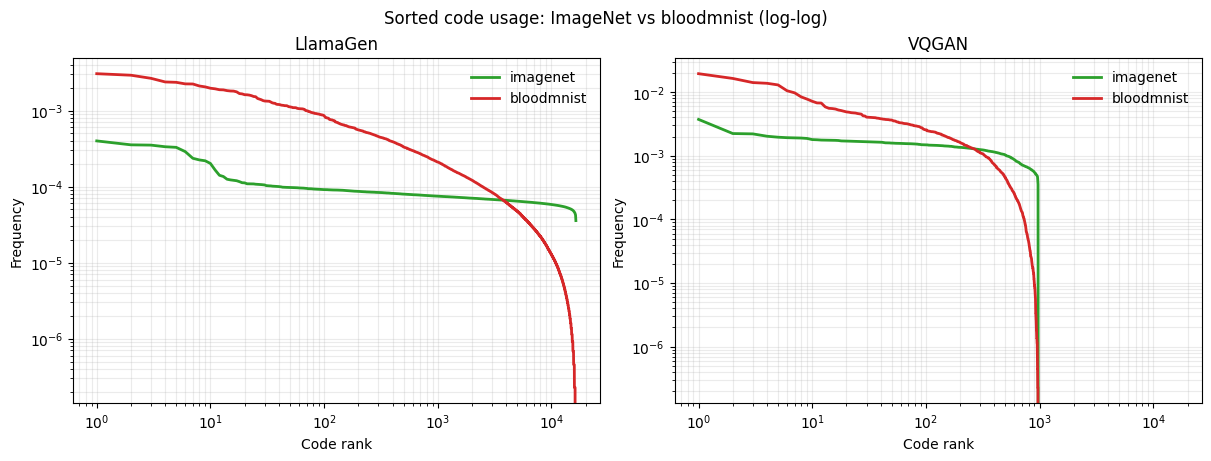

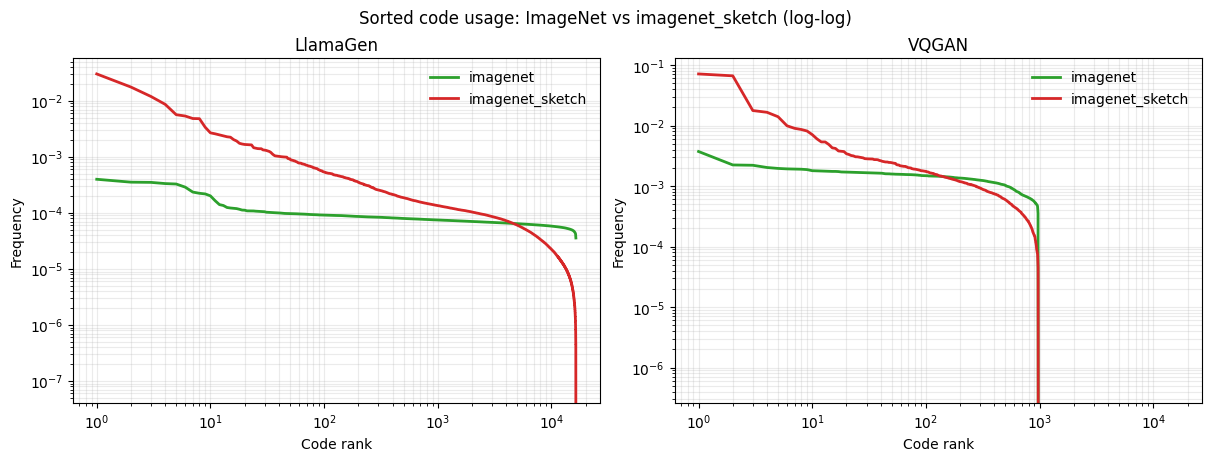

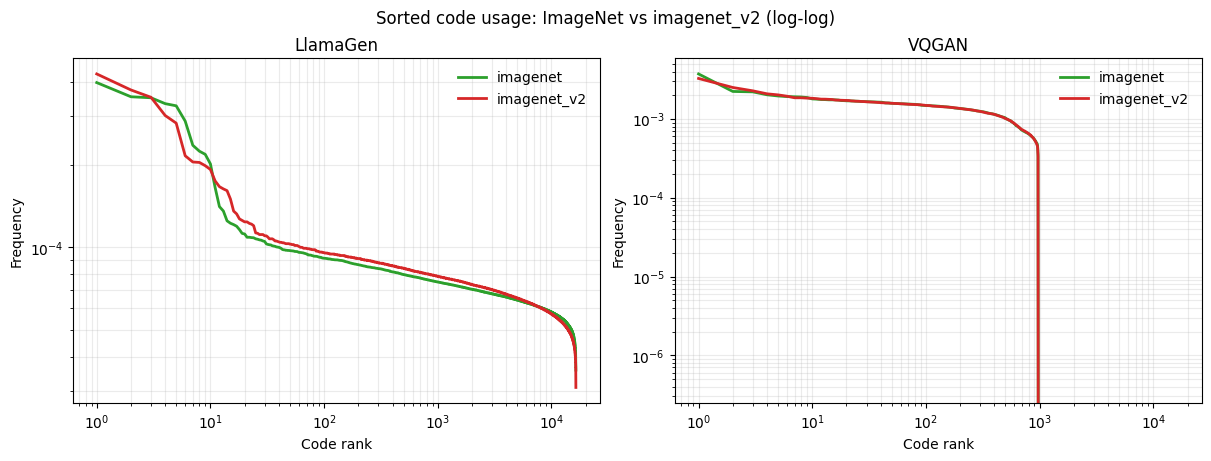

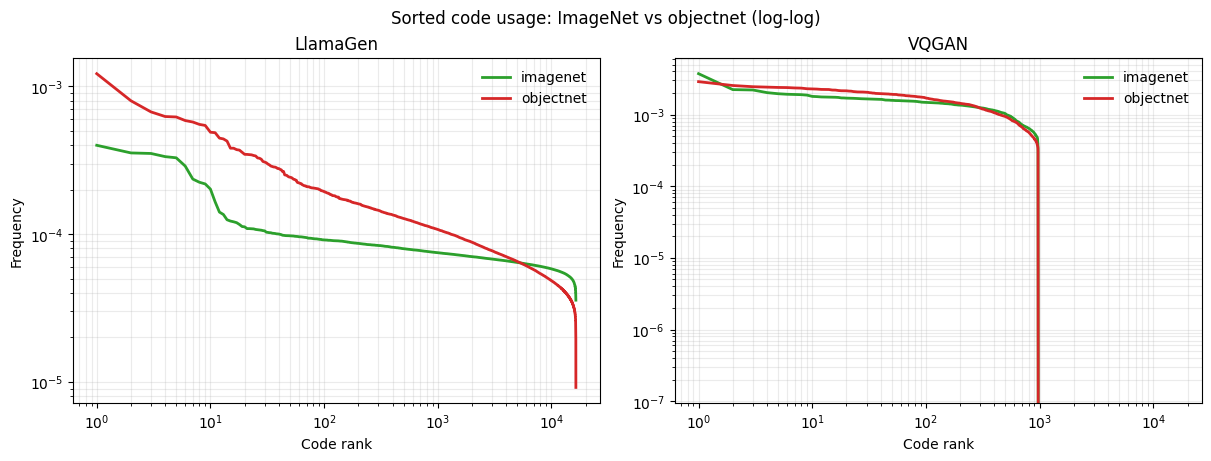

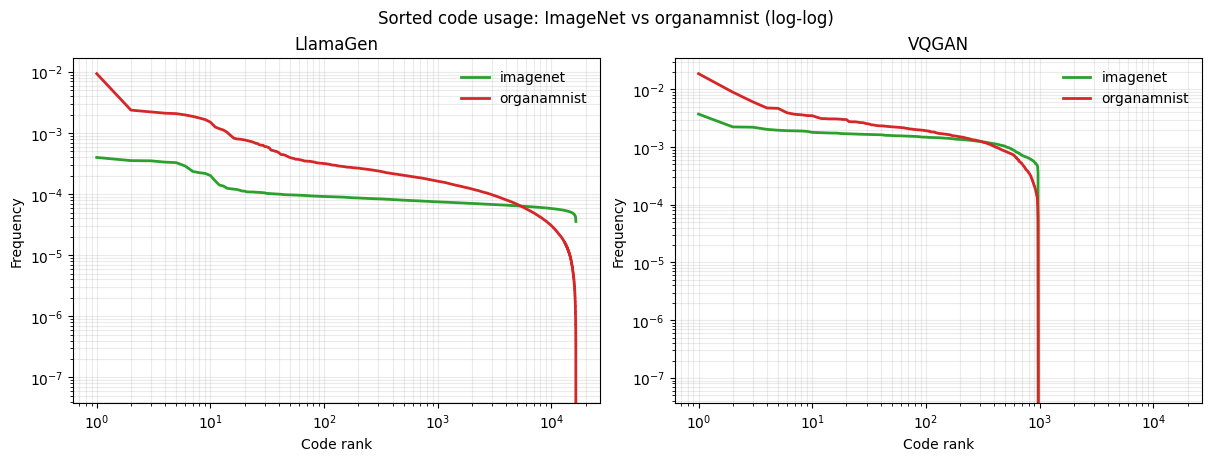

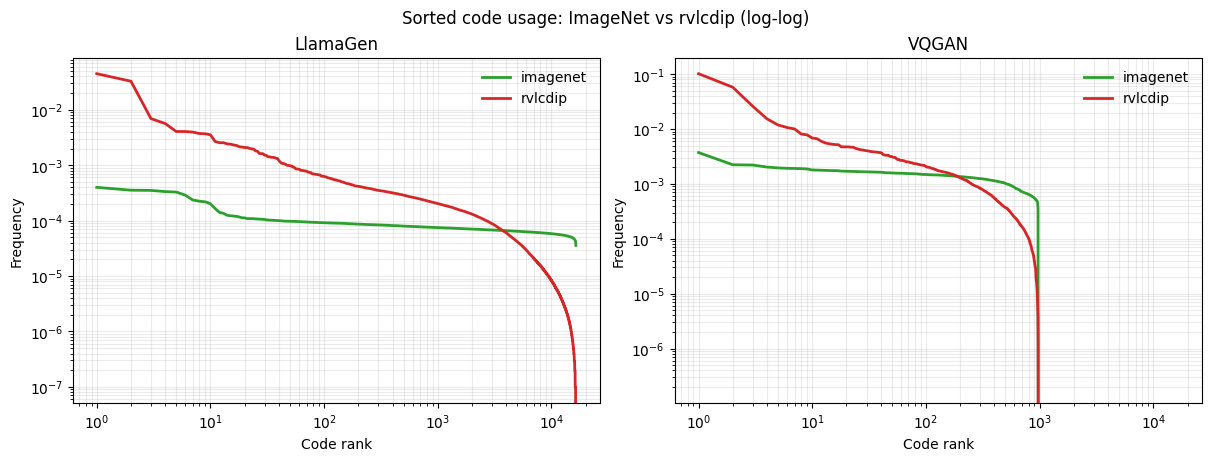

In [31]:
for ood_dataset in ood_datasets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ax, model in zip(axes, MODEL_DIRS):
        for dataset, color in [(IN_DISTRIBUTION_DATASET, 'C2'), (ood_dataset, 'C3')]:
            counts = runs[model][dataset]['global_counts']
            freqs = np.sort(counts / counts.sum())[::-1]
            ax.plot(np.arange(1, len(freqs) + 1), freqs, label=dataset, linewidth=2, color=color)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(model)
        ax.set_xlabel('Code rank')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.25, which='both')
        ax.legend(frameon=False)

    fig.suptitle(f'Sorted code usage: ImageNet vs {ood_dataset} (log-log)')
    plt.show()

# x -> rank after sorting by usage (1 = most used, 1000 = 1000th most used code)
# y -> the fraction of all token assignments taken by that ranked code


## Reconstruction Metrics Beside Code-Usage Shift

The log-log curves above show how concentrated the tokenizer vocabulary becomes under dataset shift. To make the connection to reconstruction quality visible, this section joins the code-usage summaries with the reconstruction metrics from `data/end_to_end_metrics_numeric.csv`. Each panel compares ImageNet with the current OOD dataset for the same two models, so we can see whether changes in code usage coincide with changes in PSNR, SSIM, LPIPS, FID, or related evaluator scores.


In [ ]:
recon_display_cols = [
    'model', 'dataset_label',
    'perplexity', 'top_100_mass', 'top_500_mass',
    'psnr_mean', 'psnr_std', 'ssim_mean', 'ssim_std',
    'lpips_mean', 'lpips_std', 'fid', 'sfid',
    'precision', 'recall', 'inception',
]

combined_df[recon_display_cols].sort_values(['dataset_label', 'model']).reset_index(drop=True)


In [ ]:
recon_plot_metrics = [
    ('perplexity', None, 'Code perplexity', 'higher = broader code usage'),
    ('top_100_mass', None, 'Top-100 code mass', 'higher = more concentrated'),
    ('psnr_mean', 'psnr_std', 'PSNR', 'higher = better'),
    ('ssim_mean', 'ssim_std', 'SSIM', 'higher = better'),
    ('lpips_mean', 'lpips_std', 'LPIPS', 'lower = better'),
    ('fid', None, 'FID', 'lower = better'),
]

for ood_dataset in ood_datasets:
    focus_datasets = [IN_DISTRIBUTION_DATASET, ood_dataset]
    sub = combined_df[combined_df['dataset'].isin(focus_datasets)].copy()
    sub['dataset_label'] = pd.Categorical(
        sub['dataset'].map(display_dataset_name),
        categories=[display_dataset_name(name) for name in focus_datasets],
        ordered=True,
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), constrained_layout=True)
    axes = axes.flatten()

    for ax, (metric, std_metric, title, subtitle) in zip(axes, recon_plot_metrics):
        x = np.arange(len(focus_datasets))
        width = 0.35
        for offset, model, color in [(-width / 2, 'LlamaGen', 'C0'), (width / 2, 'VQGAN', 'C1')]:
            model_sub = (
                sub[sub['model'] == model]
                .set_index('dataset')
                .loc[focus_datasets]
                .reset_index()
            )
            y = model_sub[metric].to_numpy()
            yerr = model_sub[std_metric].to_numpy() if std_metric else None
            ax.bar(
                x + offset,
                y,
                width=width,
                label=model,
                color=color,
                alpha=0.85,
                yerr=yerr,
                capsize=3 if yerr is not None else 0,
                error_kw=dict(linewidth=1, alpha=0.75),
            )
        ax.set_title(f'{title} - {subtitle}', fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels([display_dataset_name(name) for name in focus_datasets], rotation=20, ha='right')
        ax.grid(axis='y', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].legend(frameon=False, ncol=2)
    fig.suptitle(f'Code usage and reconstruction metrics: ImageNet vs {display_dataset_name(ood_dataset)}')
    save_current_plot(f'code_usage_reconstruction_metrics_{ood_dataset}')
    plt.show()


## Positional Entropy

For each location in the `16 x 16` token grid, this computes the entropy of `P(code | position)`: across all images, how diverse are the codes that appear at this exact grid cell?

The raw entropy scale is not comparable between LlamaGen and VQGAN because LlamaGen uses almost the full 16k-code vocabulary while VQGAN uses roughly 1k active codes. To make the heatmaps visually meaningful, each model row is normalized independently using that model's ImageNet/OOD pair. The colors should be read as relative spatial variation within a model, not as an absolute comparison between models. The delta plot underneath shows `OOD - ImageNet` in raw entropy units for each model.


saved: code_usage_plots/entropy_row_normalized_bloodmnist.png


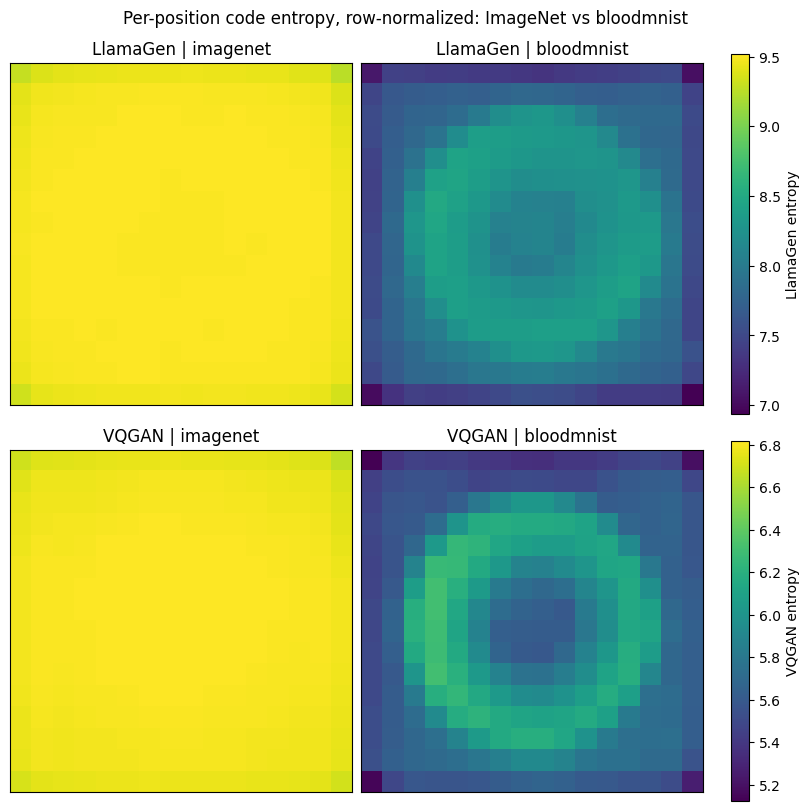

saved: code_usage_plots/entropy_delta_bloodmnist.png


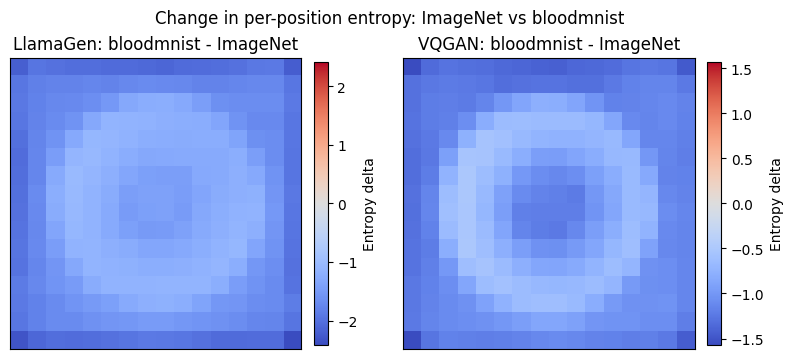

saved: code_usage_plots/entropy_row_normalized_imagenet_sketch.png


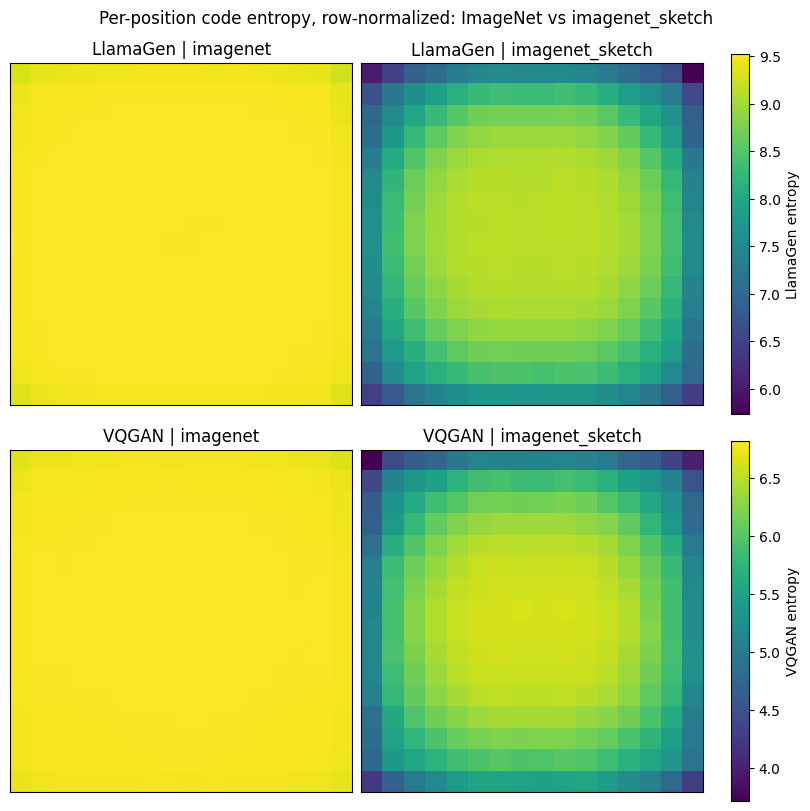

saved: code_usage_plots/entropy_delta_imagenet_sketch.png


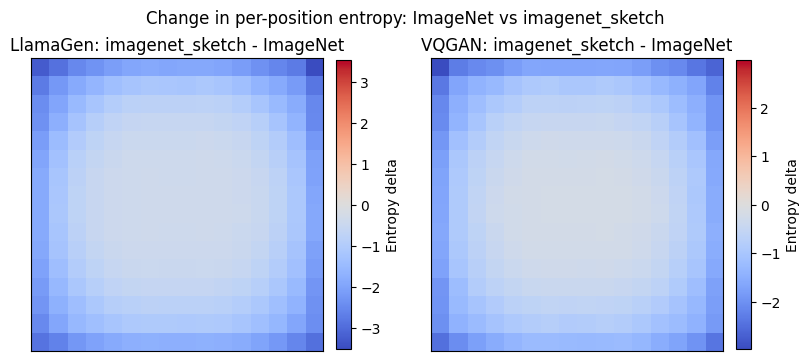

saved: code_usage_plots/entropy_row_normalized_imagenet_v2.png


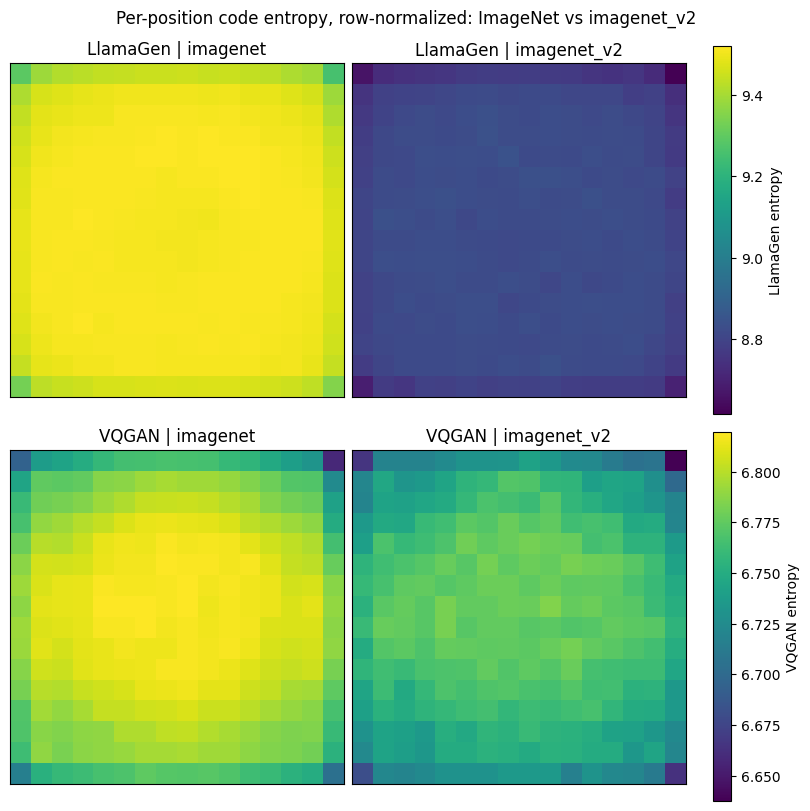

saved: code_usage_plots/entropy_delta_imagenet_v2.png


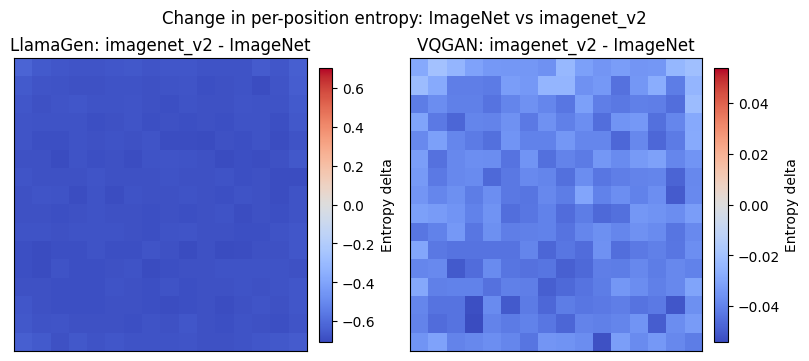

saved: code_usage_plots/entropy_row_normalized_objectnet.png


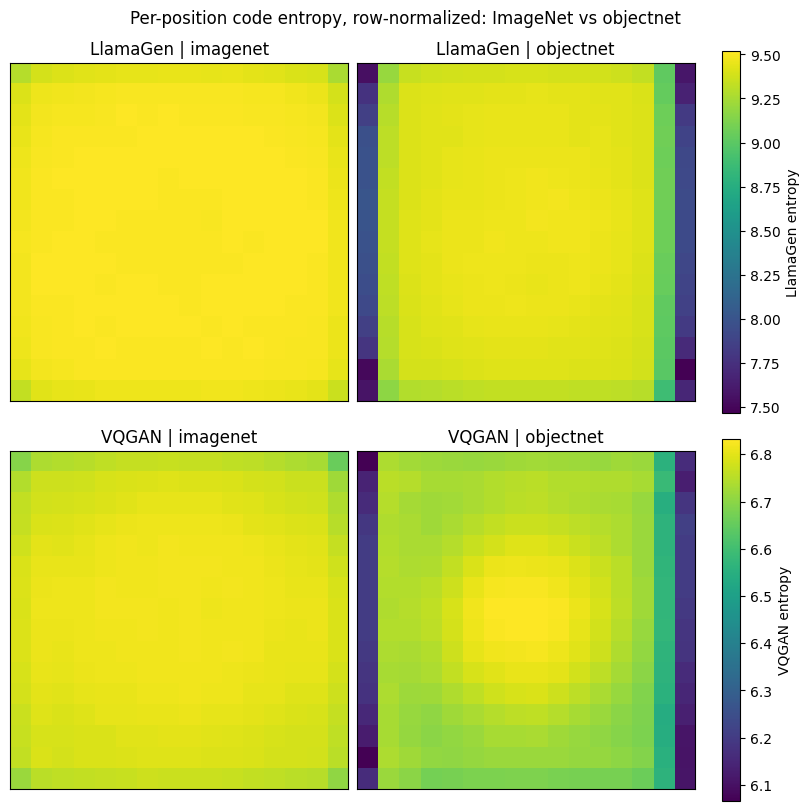

saved: code_usage_plots/entropy_delta_objectnet.png


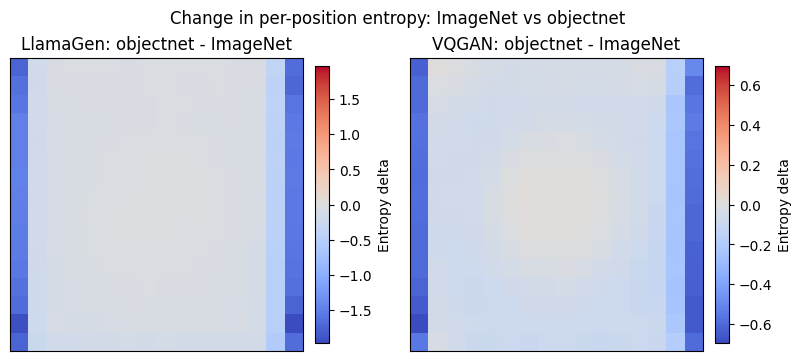

saved: code_usage_plots/entropy_row_normalized_organamnist.png


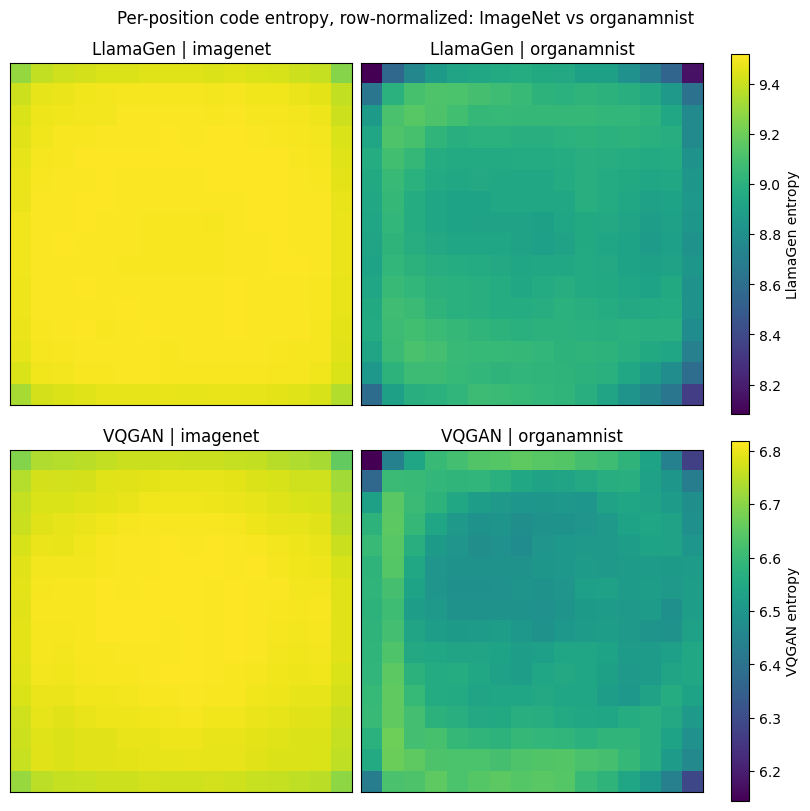

saved: code_usage_plots/entropy_delta_organamnist.png


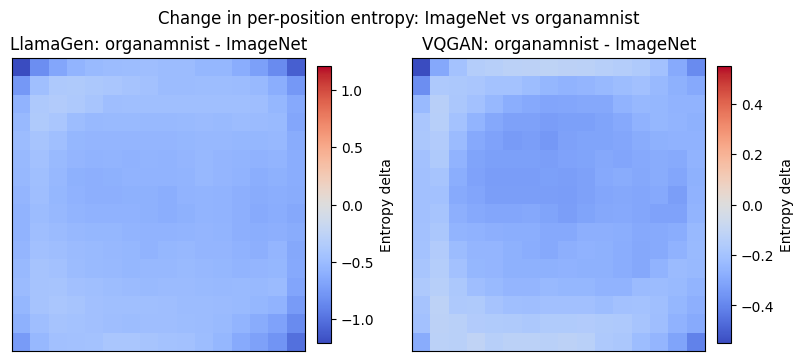

saved: code_usage_plots/entropy_row_normalized_rvlcdip.png


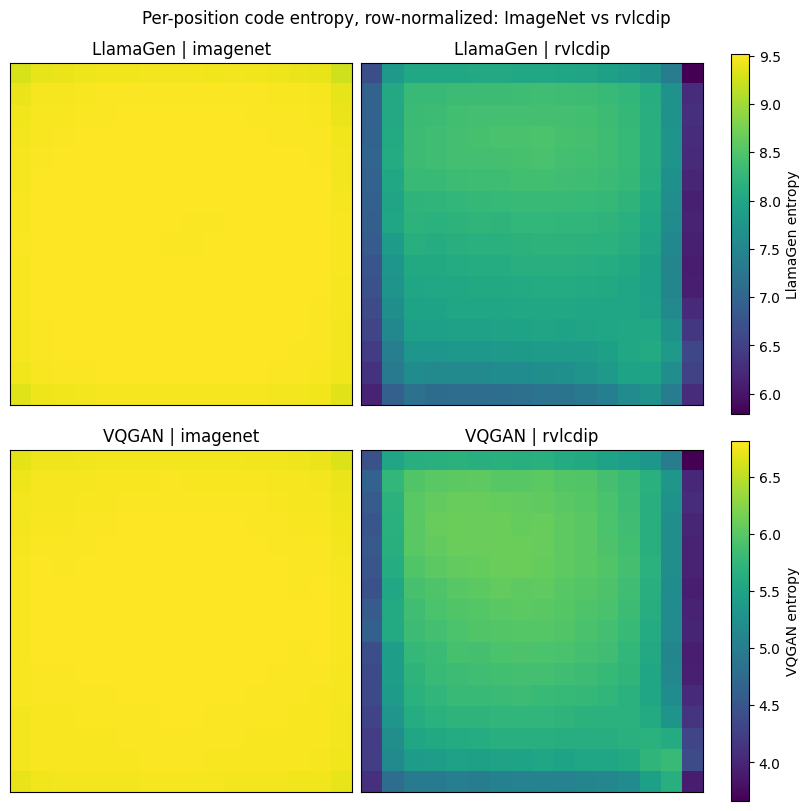

saved: code_usage_plots/entropy_delta_rvlcdip.png


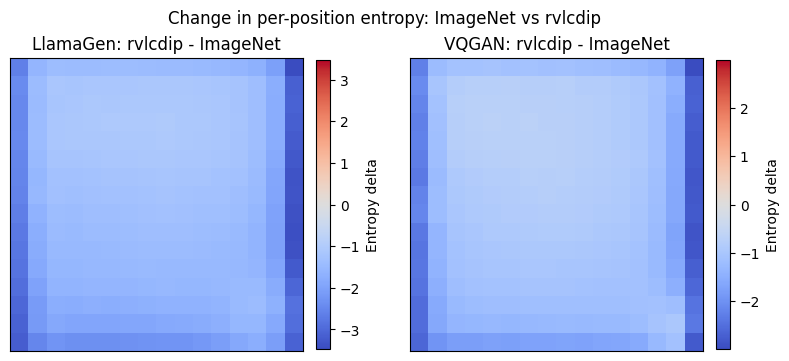

In [51]:
for ood_dataset in ood_datasets:
    focus_datasets = [IN_DISTRIBUTION_DATASET, ood_dataset]
    entropy_grids = {
        model: {
            dataset: position_entropy(runs[model][dataset]['position_counts'])
            for dataset in focus_datasets
        }
        for model in MODEL_DIRS
    }

    fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)

    for row, model in enumerate(MODEL_DIRS):
        model_values = [entropy_grids[model][dataset] for dataset in focus_datasets]
        vmin = min(grid.min() for grid in model_values)
        vmax = max(grid.max() for grid in model_values)
        for col, dataset in enumerate(focus_datasets):
            ax = axes[row, col]
            im = ax.imshow(entropy_grids[model][dataset], vmin=vmin, vmax=vmax, cmap='viridis')
            ax.set_title(f'{model} | {dataset}')
            ax.set_xticks([])
            ax.set_yticks([])
        fig.colorbar(im, ax=axes[row, :], fraction=0.046, pad=0.04, label=f'{model} entropy')

    fig.suptitle(f'Per-position code entropy, row-normalized: ImageNet vs {ood_dataset}')
    save_current_plot(f"entropy_row_normalized_{ood_dataset}")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
    for ax, model in zip(axes, MODEL_DIRS):
        delta = entropy_grids[model][ood_dataset] - entropy_grids[model][IN_DISTRIBUTION_DATASET]
        vmax = np.abs(delta).max()
        im = ax.imshow(delta, vmin=-vmax, vmax=vmax, cmap='coolwarm')
        ax.set_title(f'{model}: {ood_dataset} - ImageNet')
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Entropy delta')

    fig.suptitle(f'Change in per-position entropy: ImageNet vs {ood_dataset}')
    save_current_plot(f"entropy_delta_{ood_dataset}")
    plt.show()


## Where Individual Codes Appear

For a fixed code ID, the heatmap estimates `P(position | code)`: when this code appears, where in the `16 x 16` grid does it appear? This is different from the entropy plot above. Here the question is code-specific spatial deployment.

The main hypothesis is that dataset shift may change not only how often a code is used, but also how spatially spread out that code is. A code can become more concentrated under OOD data, producing more black cells and a few brighter cells. To make this measurable, we compute per-code position perplexity, zero-position fraction, max-position mass, and the L1 distance between the ImageNet and OOD position maps.


In [46]:
CODE_IDS_TO_VIEW = alive_in_both[:3]

saved: code_usage_plots/code_23_spatial_deployment_bloodmnist.png


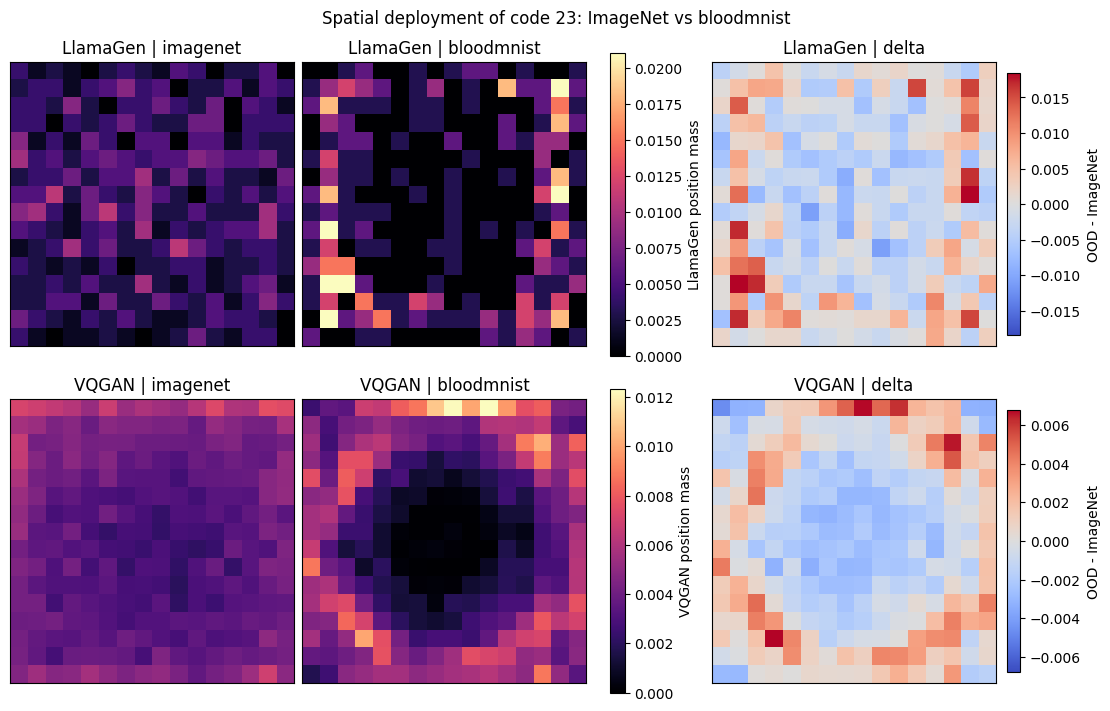

saved: code_usage_plots/code_66_spatial_deployment_bloodmnist.png


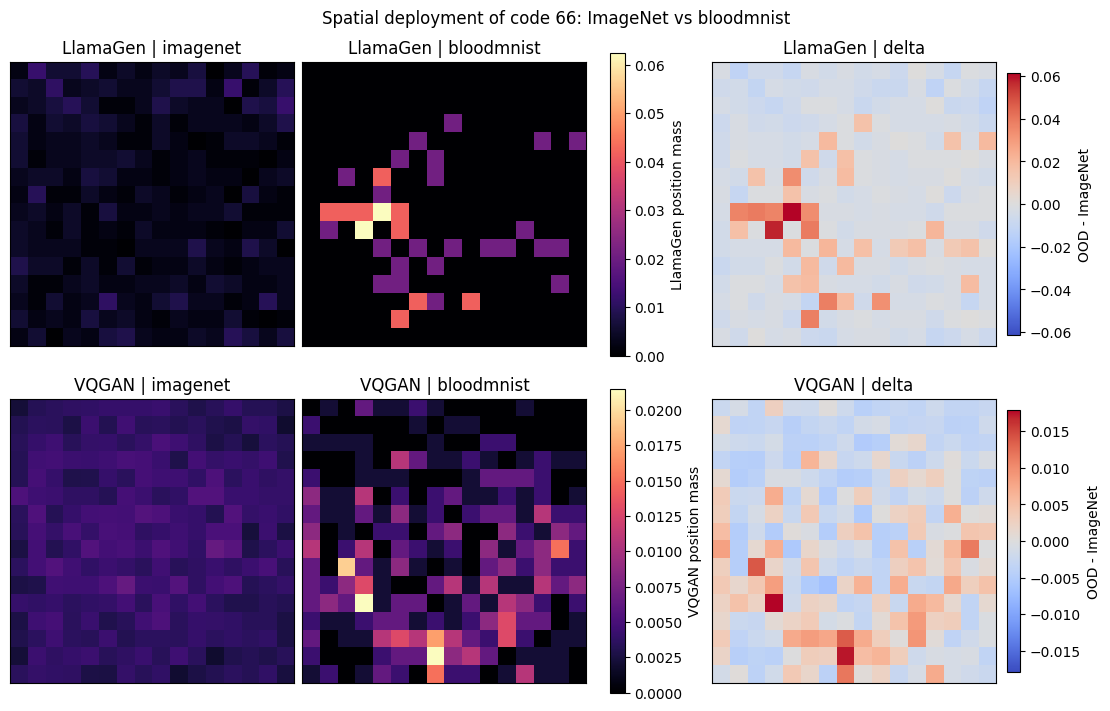

saved: code_usage_plots/code_81_spatial_deployment_bloodmnist.png


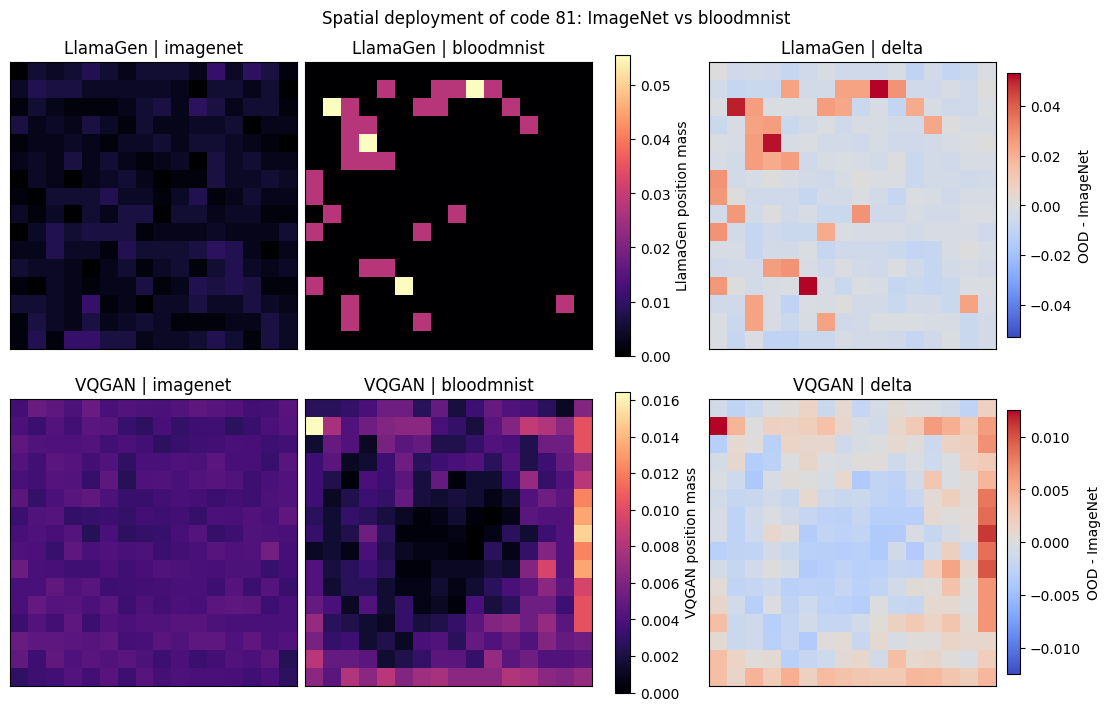

saved: code_usage_plots/code_23_spatial_deployment_imagenet_sketch.png


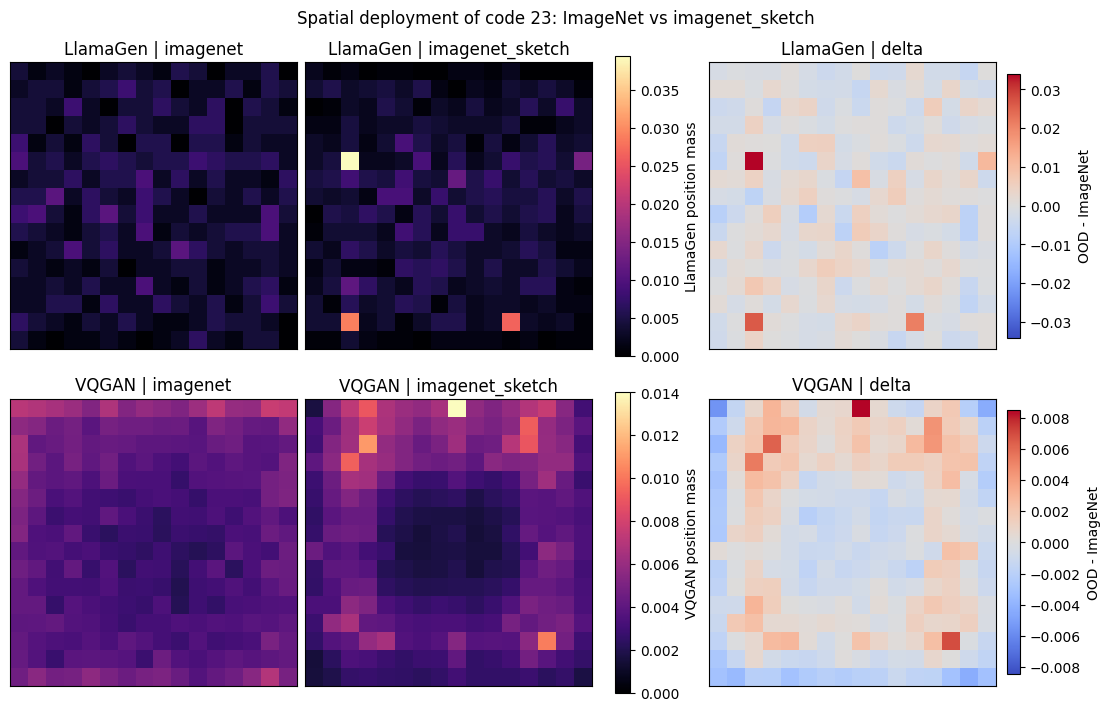

saved: code_usage_plots/code_66_spatial_deployment_imagenet_sketch.png


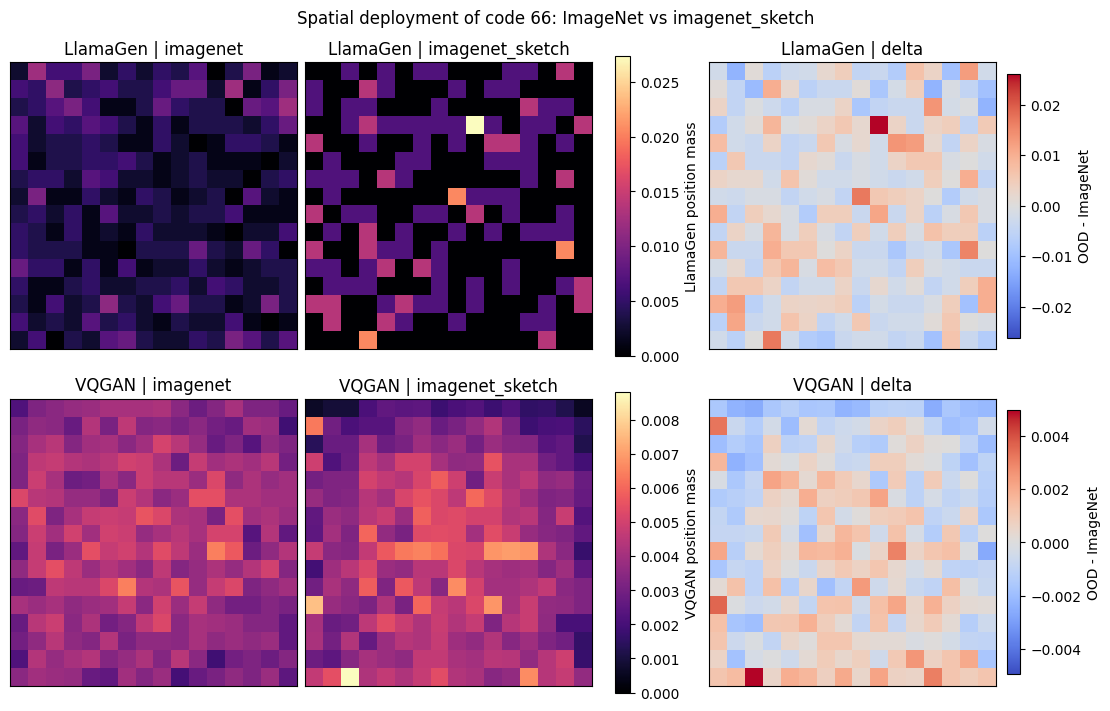

saved: code_usage_plots/code_81_spatial_deployment_imagenet_sketch.png


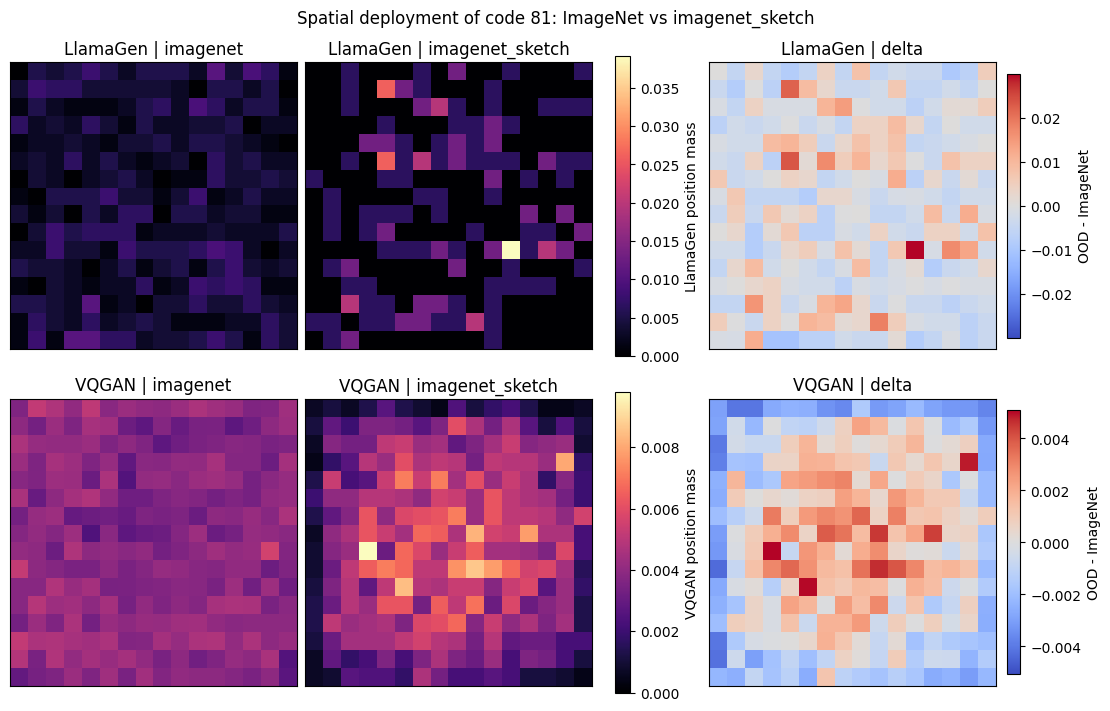

saved: code_usage_plots/code_23_spatial_deployment_imagenet_v2.png


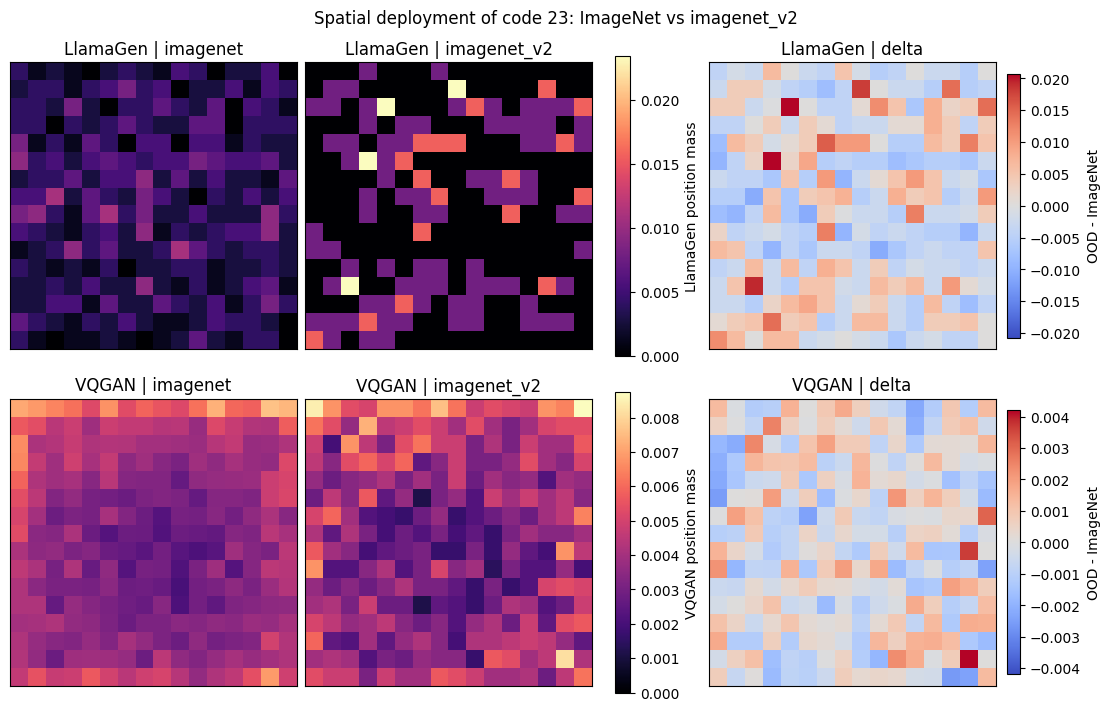

saved: code_usage_plots/code_66_spatial_deployment_imagenet_v2.png


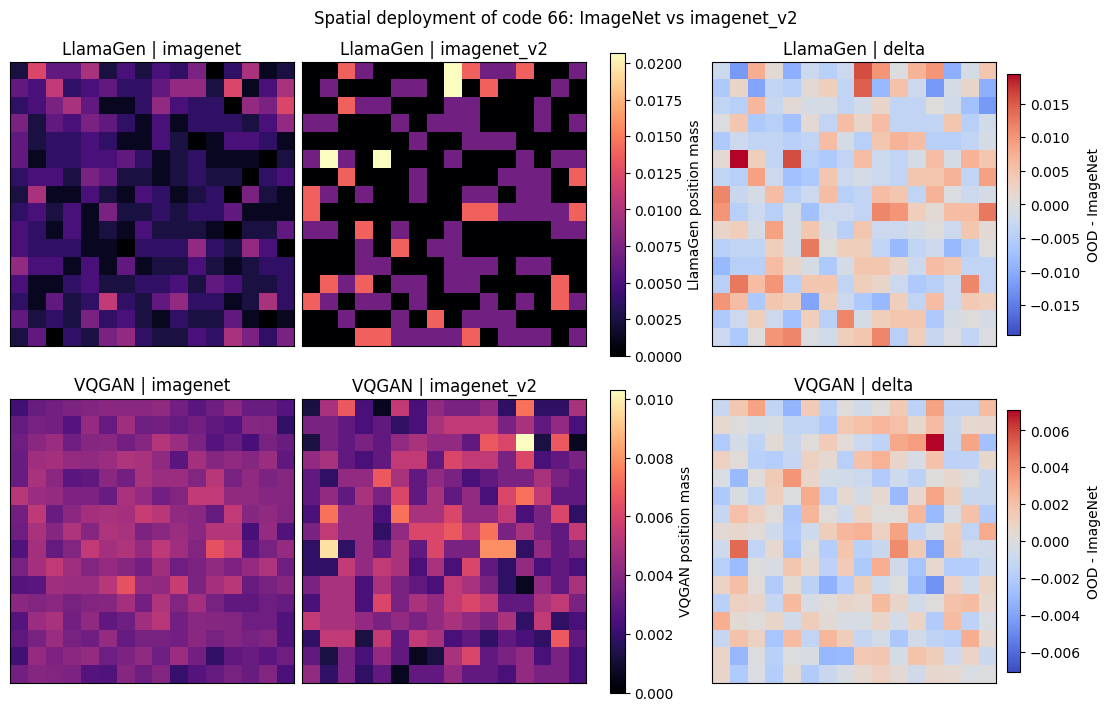

saved: code_usage_plots/code_81_spatial_deployment_imagenet_v2.png


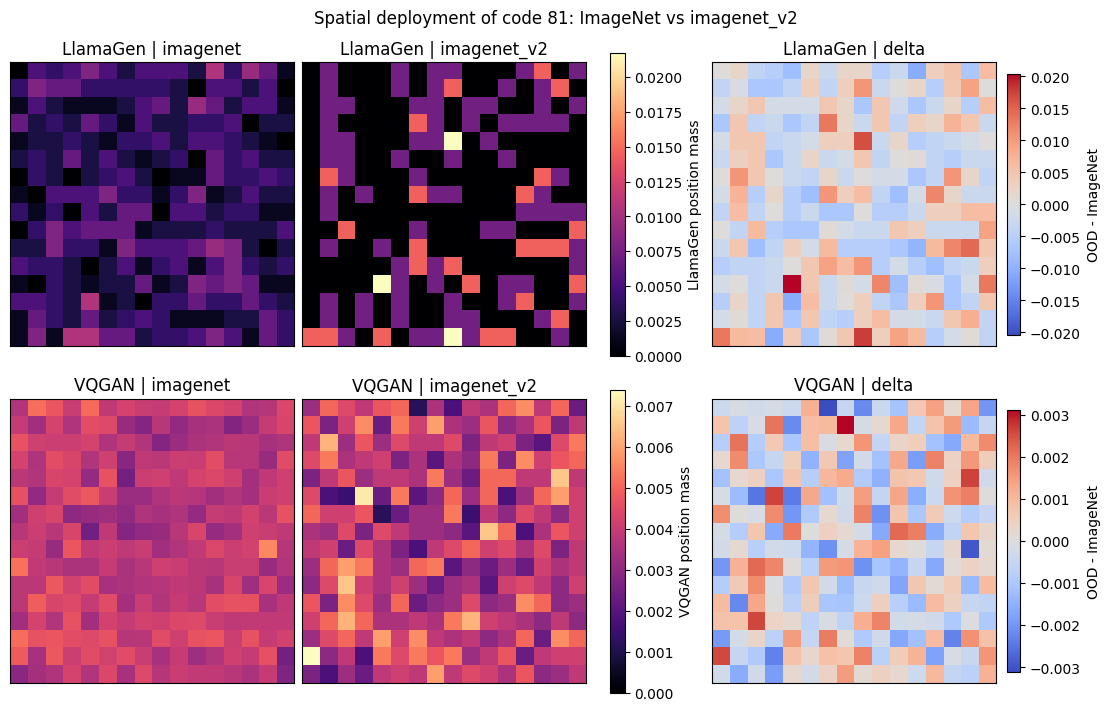

saved: code_usage_plots/code_23_spatial_deployment_objectnet.png


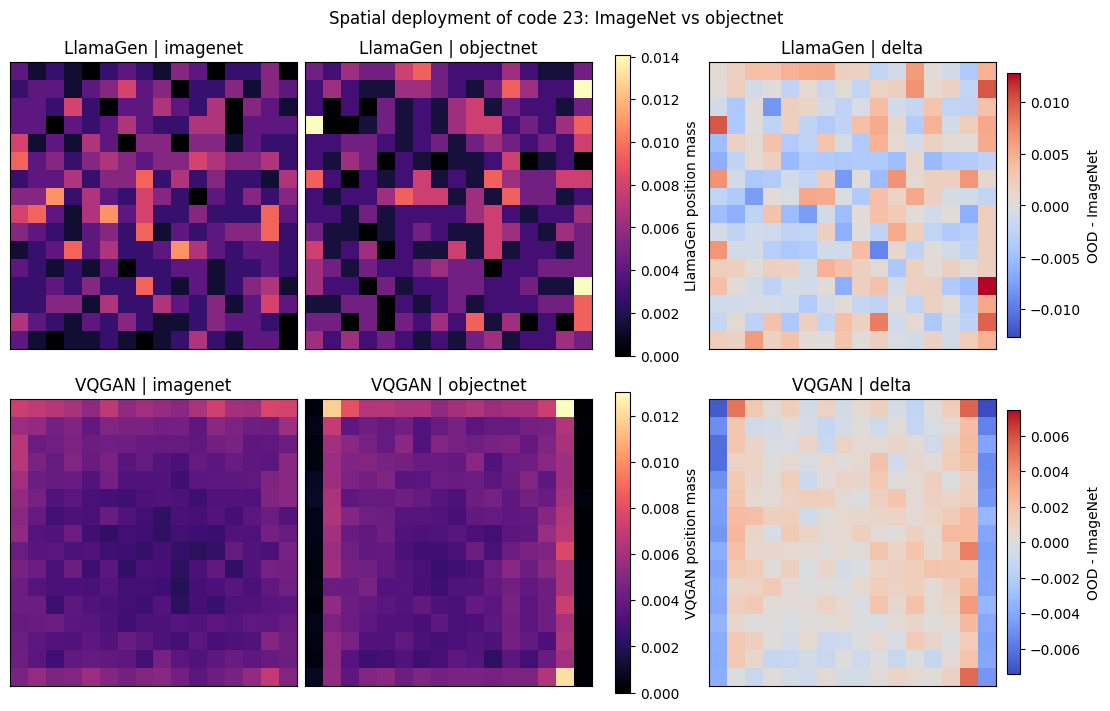

saved: code_usage_plots/code_66_spatial_deployment_objectnet.png


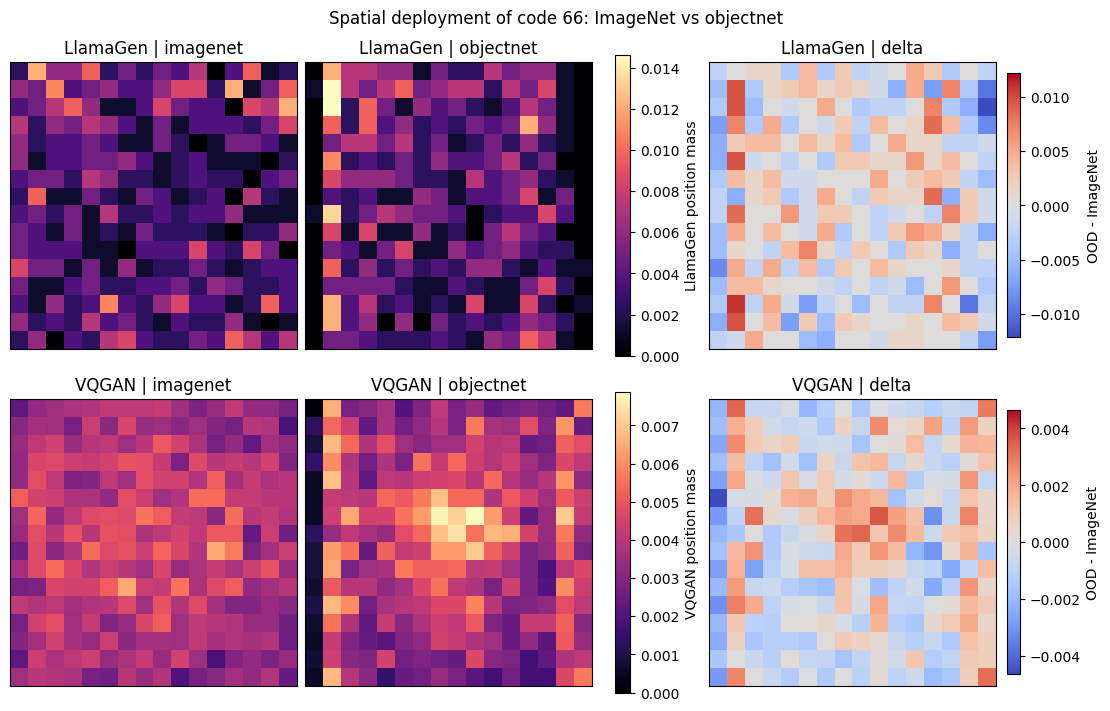

saved: code_usage_plots/code_81_spatial_deployment_objectnet.png


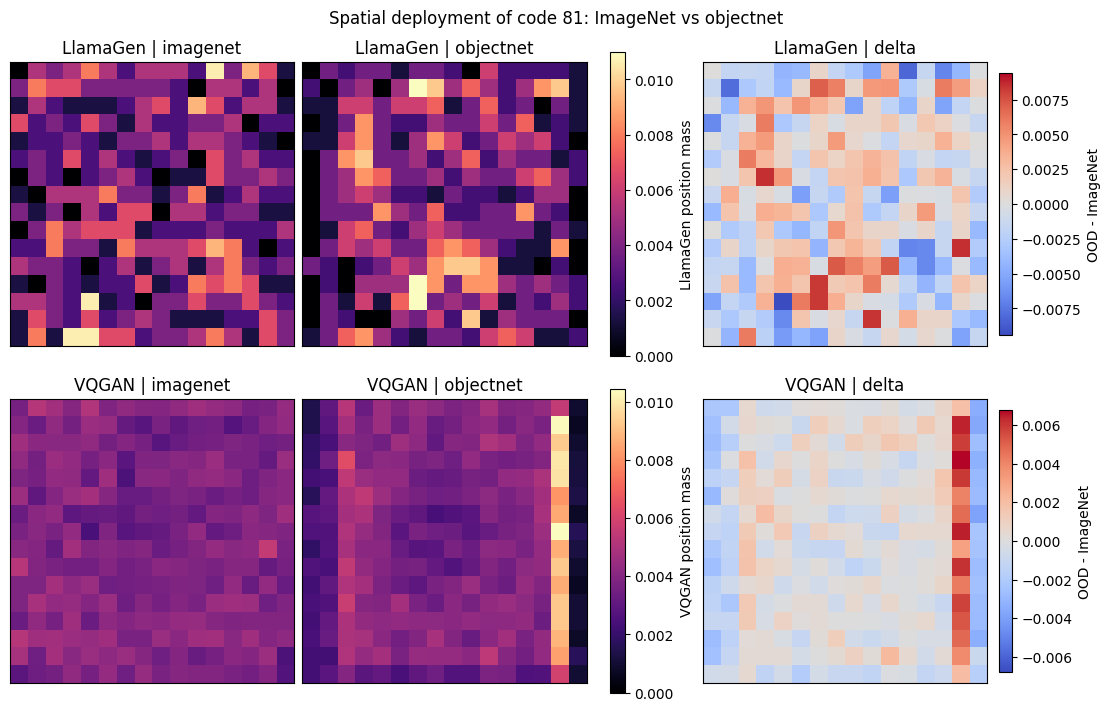

saved: code_usage_plots/code_23_spatial_deployment_organamnist.png


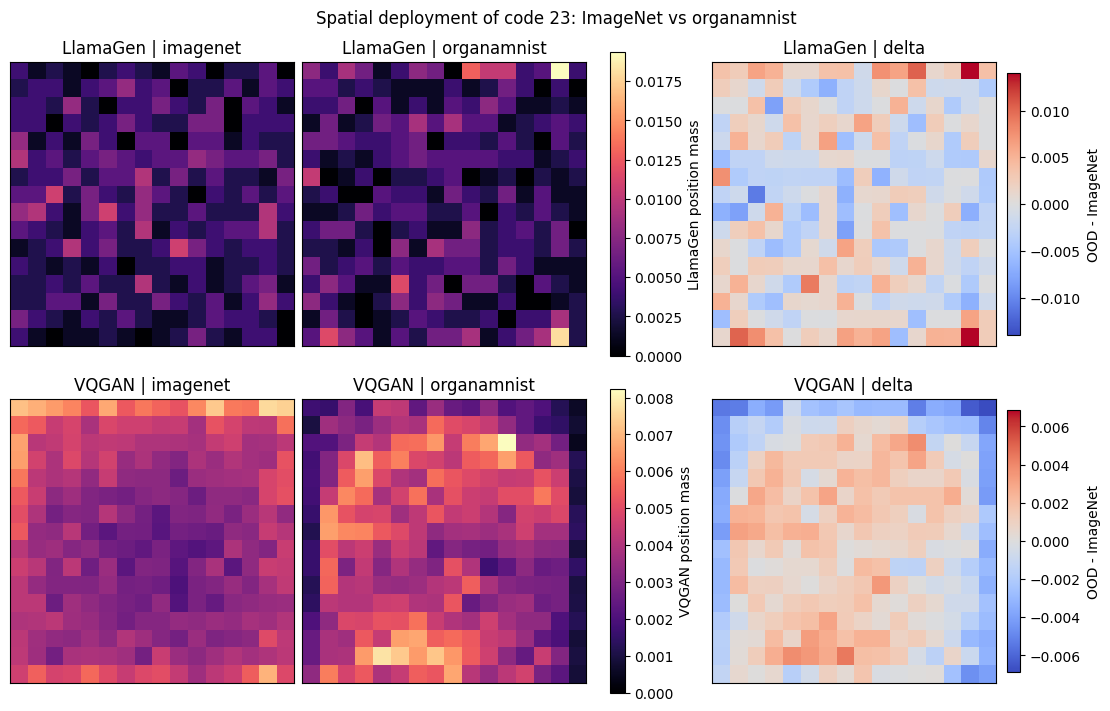

saved: code_usage_plots/code_66_spatial_deployment_organamnist.png


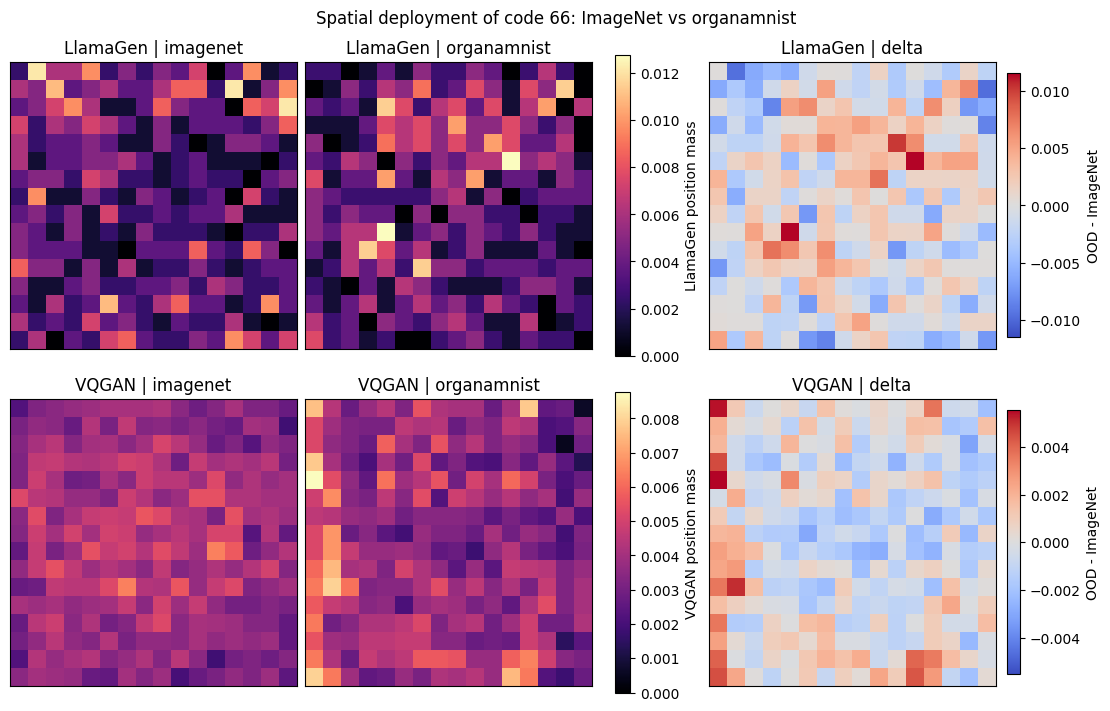

saved: code_usage_plots/code_81_spatial_deployment_organamnist.png


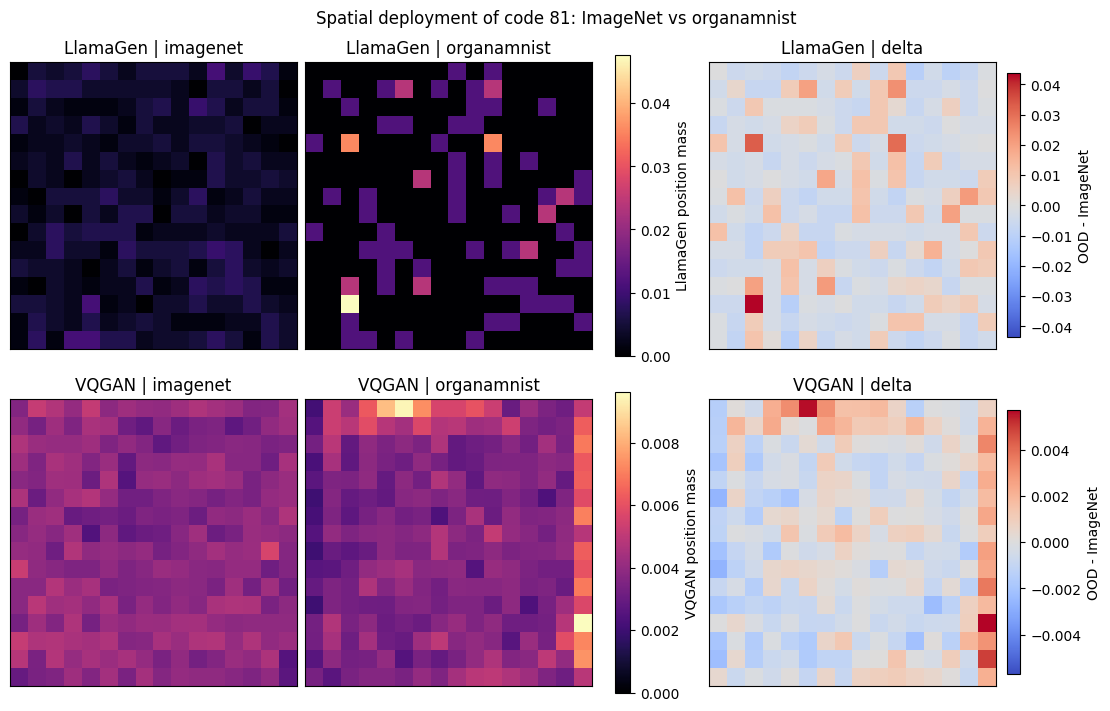

saved: code_usage_plots/code_23_spatial_deployment_rvlcdip.png


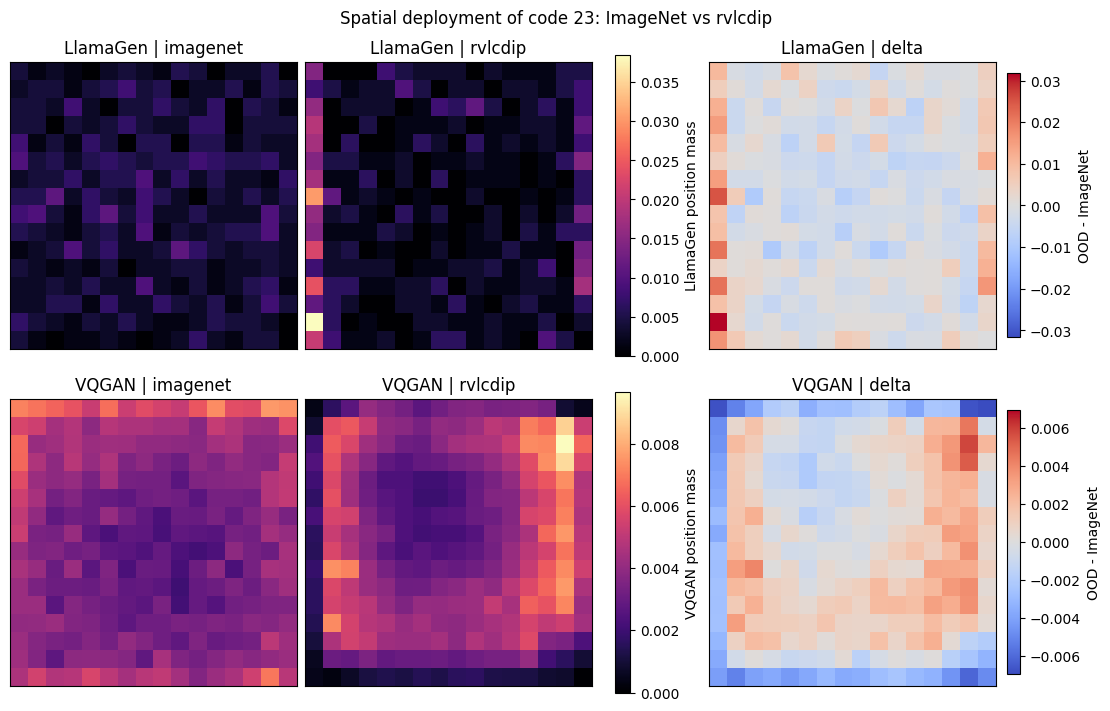

saved: code_usage_plots/code_66_spatial_deployment_rvlcdip.png


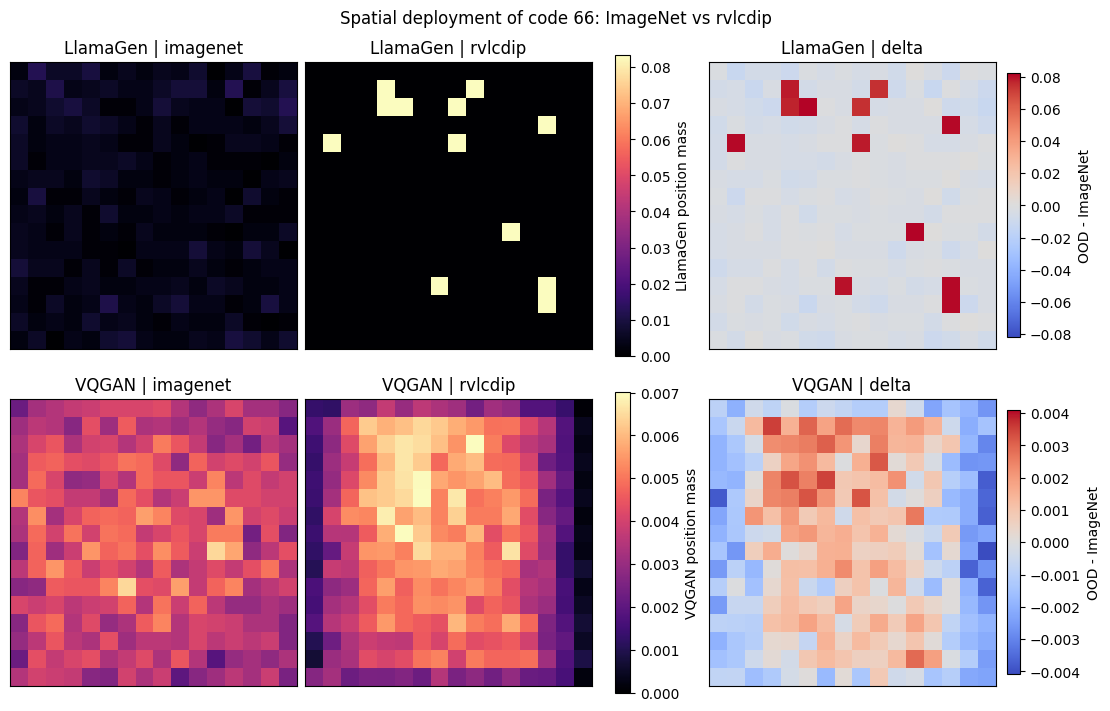

saved: code_usage_plots/code_81_spatial_deployment_rvlcdip.png


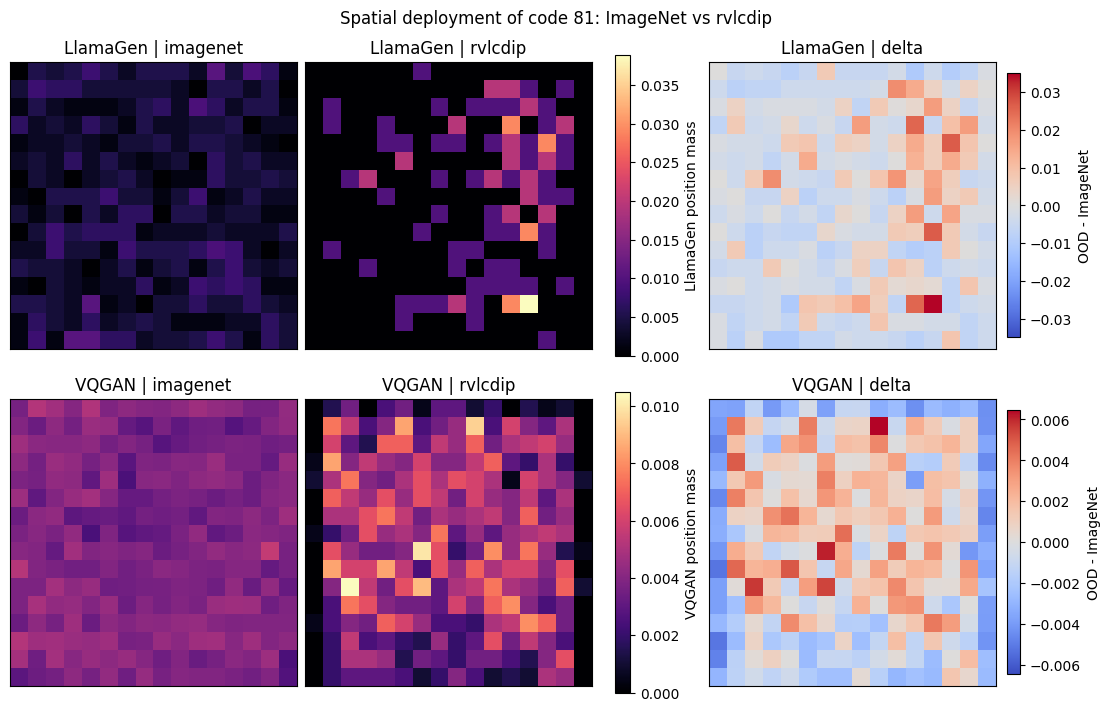

,code_id,code_total,position_entropy,position_perplexity,zero_position_fraction,max_position_mass,model,dataset,ood_dataset,l1_vs_imagenet
0,23,332,4.759770,116.719036,0.421875,0.021084,LlamaGen,bloodmnist,bloodmnist,1.067080
1,23,739,5.356751,212.034861,0.062500,0.010825,LlamaGen,imagenet,bloodmnist,0.000000
2,23,739,5.356751,212.034861,0.062500,0.010825,LlamaGen,imagenet,imagenet_sketch,0.000000
3,23,1317,5.233408,187.430549,0.046875,0.039484,LlamaGen,imagenet_sketch,imagenet_sketch,0.676409
4,23,739,5.356751,212.034861,0.062500,0.010825,LlamaGen,imagenet,imagenet_v2,0.000000
...,...,...,...,...,...,...,...,...,...,...
67,81,19843,5.461909,235.546613,0.000000,0.010432,VQGAN,objectnet,objectnet,0.278175
68,81,17388,5.536058,253.676015,0.000000,0.005579,VQGAN,imagenet,organamnist,0.000000
69,81,18495,5.507589,246.555991,0.000000,0.009624,VQGAN,organamnist,organamnist,0.231462
70,81,17388,5.536058,253.676015,0.000000,0.005579,VQGAN,imagenet,rvlcdip,0.000000


In [49]:
code_position_rows = []

for ood_dataset in ood_datasets:
    focus_datasets = [IN_DISTRIBUTION_DATASET, ood_dataset]
    for code_id in CODE_IDS_TO_VIEW:
        for model in MODEL_DIRS:
            baseline_counts = runs[model][IN_DISTRIBUTION_DATASET]['position_counts']
            for dataset in focus_datasets:
                counts = runs[model][dataset]['position_counts']
                stats = code_position_stats(counts, code_id)
                stats.update({
                    'model': model,
                    'dataset': dataset,
                    'ood_dataset': ood_dataset,
                    'l1_vs_imagenet': code_position_l1_distance(baseline_counts, counts, code_id),
                })
                code_position_rows.append(stats)

        fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
        maps = {
            model: {
                dataset: normalized_code_position_map(runs[model][dataset]['position_counts'], code_id)
                for dataset in focus_datasets
            }
            for model in MODEL_DIRS
        }

        for row, model in enumerate(MODEL_DIRS):
            model_maps = [maps[model][dataset] for dataset in focus_datasets]
            vmax = max(grid.max() for grid in model_maps)
            for col, dataset in enumerate(focus_datasets):
                ax = axes[row, col]
                im = ax.imshow(maps[model][dataset], vmin=0.0, vmax=vmax, cmap='magma')
                ax.set_title(f'{model} | {dataset}')
                ax.set_xticks([])
                ax.set_yticks([])

            delta = maps[model][ood_dataset] - maps[model][IN_DISTRIBUTION_DATASET]
            delta_vmax = np.abs(delta).max()
            ax = axes[row, 2]
            im_delta = ax.imshow(delta, vmin=-delta_vmax, vmax=delta_vmax, cmap='coolwarm')
            ax.set_title(f'{model} | delta')
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=axes[row, :2], fraction=0.046, pad=0.04, label=f'{model} position mass')
            fig.colorbar(im_delta, ax=ax, fraction=0.046, pad=0.04, label='OOD - ImageNet')

        fig.suptitle(f'Spatial deployment of code {code_id}: ImageNet vs {ood_dataset}')
        save_current_plot(f"code_{code_id}_spatial_deployment_{ood_dataset}")
        plt.show()
       

code_position_df = pd.DataFrame(code_position_rows)
code_position_df.sort_values(['code_id', 'model', 'ood_dataset', 'dataset']).reset_index(drop=True)


## Code-Specific Spatial Diffusion Summary

The table below turns the code-position heatmap intuition into scalar quantities. `position_perplexity` is the effective number of grid cells used by a code. `zero_position_fraction` is the fraction of the `16 x 16` cells where the code never appears. `max_position_mass` is how much of the code's total usage is concentrated in its strongest grid cell. `l1_vs_imagenet` measures how much the OOD spatial map differs from the ImageNet map for the same model and code.


In [34]:
display_cols = [
    'model', 'ood_dataset', 'dataset', 'code_id', 'code_total',
    'position_perplexity', 'zero_position_fraction', 'max_position_mass', 'l1_vs_imagenet'
]
code_position_df[display_cols].sort_values(['code_id', 'model', 'ood_dataset', 'dataset']).reset_index(drop=True)


,model,ood_dataset,dataset,code_id,code_total,position_perplexity,zero_position_fraction,max_position_mass,l1_vs_imagenet
0,LlamaGen,bloodmnist,bloodmnist,0,2200,203.599093,0.035156,0.012727,0.611761
1,LlamaGen,bloodmnist,imagenet,0,898,215.113796,0.039062,0.013363,0.000000
2,LlamaGen,imagenet_sketch,imagenet,0,898,215.113796,0.039062,0.013363,0.000000
3,LlamaGen,imagenet_sketch,imagenet_sketch,0,1105,192.019094,0.050781,0.019005,0.667466
4,LlamaGen,imagenet_v2,imagenet,0,898,215.113796,0.039062,0.013363,0.000000
5,LlamaGen,imagenet_v2,imagenet_v2,0,208,131.691989,0.429688,0.024038,0.973317
6,LlamaGen,objectnet,imagenet,0,898,215.113796,0.039062,0.013363,0.000000
7,LlamaGen,objectnet,objectnet,0,1326,204.048291,0.113281,0.011312,0.670328
8,LlamaGen,organamnist,imagenet,0,898,215.113796,0.039062,0.013363,0.000000
9,LlamaGen,organamnist,organamnist,0,2769,233.964205,0.003906,0.009390,0.593195


saved: code_usage_plots/code_23_spatial_diffusion_metrics.png


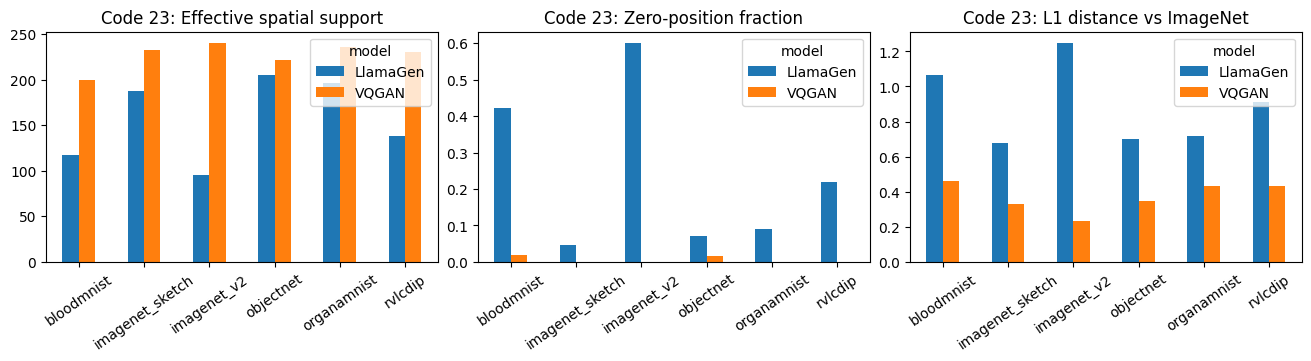

saved: code_usage_plots/code_66_spatial_diffusion_metrics.png


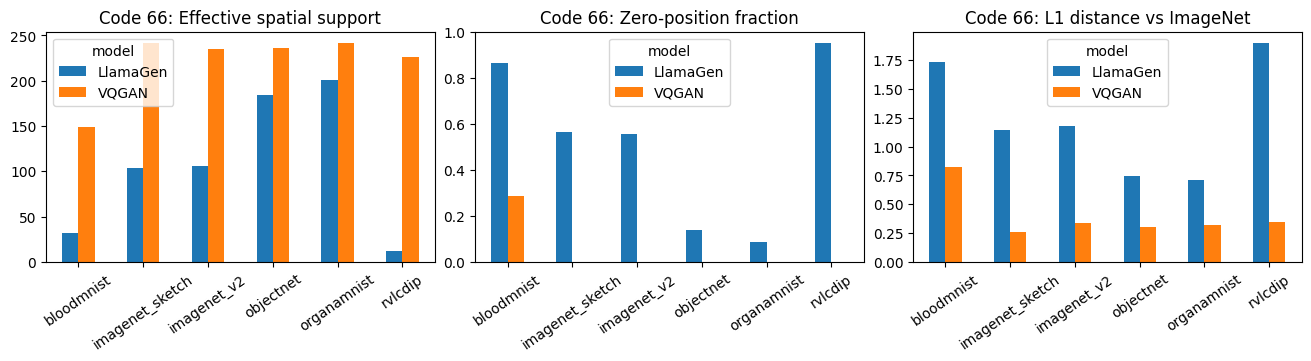

saved: code_usage_plots/code_81_spatial_diffusion_metrics.png


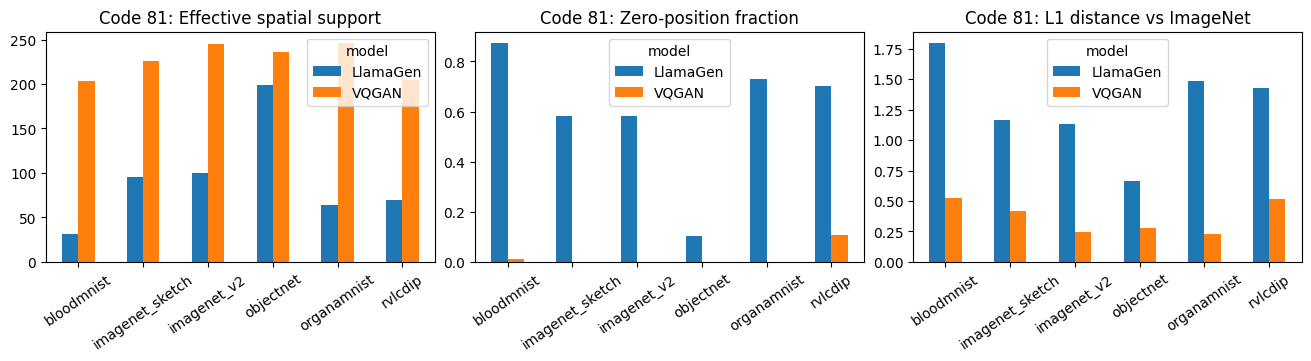

In [52]:
ood_only = code_position_df[code_position_df['dataset'] != IN_DISTRIBUTION_DATASET].copy()

for code_id in CODE_IDS_TO_VIEW:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
    subset = ood_only[ood_only['code_id'] == code_id]
    metrics = [
        ('position_perplexity', 'Effective spatial support'),
        ('zero_position_fraction', 'Zero-position fraction'),
        ('l1_vs_imagenet', 'L1 distance vs ImageNet'),
    ]
    for ax, (metric, title) in zip(axes, metrics):
        pivot = subset.pivot(index='ood_dataset', columns='model', values=metric).sort_index()
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(f'Code {code_id}: {title}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=35)
    save_current_plot(f"code_{code_id}_spatial_diffusion_metrics")
    plt.show()
